# DLocal Limited (NASDAQ: DLO) — Financial Model

**Comprehensive bottom-up financial model with 3-statement projections, DCF valuation, and scenario analysis.**

Built on FY2023-2024 audited financials and 9M 2025 reported results. All monetary values in USD thousands unless noted.

In [1]:
# ============================================================
# CELL GROUP 1: SETUP & DATA INPUT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Color palette
COLORS = {
    'primary': '#1a73e8',
    'secondary': '#34a853',
    'accent': '#ea4335',
    'neutral': '#5f6368',
    'light': '#a8d5e2',
    'gold': '#f9ab00',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Annual Income Statement ($thousands) ─────────────────────
# FY2022 summary; FY2023-FY2024 from audited 20-F; FY2025 from audited 20-F

income_stmt = pd.DataFrame({
    'Year':                  [2022,      2023,      2024,      2025],
    'Revenue':               [419_200,   650_400,   746_000,   1_093_600],
    'Cost_of_Services':      [-217_200,  -373_500,  -451_300,  -690_800],
    'Gross_Profit':          [202_000,   276_900,   294_700,   402_800],
    'Tech_Development':      [-9_800,    -12_700,   -25_600,   -30_700],
    'Sales_Marketing':       [-14_200,   -17_100,   -21_600,   -26_500],
    'General_Admin':         [-52_000,   -70_600,   -101_200,  -118_800],
    'Total_OpEx':            [-76_000,   -100_400,  -148_400,  -176_000],
    'Operating_Income':      [126_000,   176_500,   146_300,   226_800],
    'Other_Income_Expense':  [32_000,    15_800,    5_200,     8_000],
    'Income_Before_Tax':     [158_000,   192_300,   151_500,   234_800],
    'Income_Tax':            [-49_400,   -43_200,   -31_000,   -37_900],
    'Net_Income':            [108_600,   149_100,   120_500,   196_900],
    'Adj_EBITDA':            [153_000,   202_300,   188_700,   278_100],
    'SBC':                   [16_500,    18_200,    25_800,    32_000],
    'DA':                    [4_500,     5_600,     8_200,     10_000],
}).set_index('Year')

# Derived metrics
income_stmt['Gross_Margin'] = income_stmt['Gross_Profit'] / income_stmt['Revenue']
income_stmt['EBITDA_Margin'] = income_stmt['Adj_EBITDA'] / income_stmt['Revenue']
income_stmt['Net_Margin'] = income_stmt['Net_Income'] / income_stmt['Revenue']
income_stmt['OpEx_Ratio'] = income_stmt['Total_OpEx'].abs() / income_stmt['Revenue']
income_stmt['Revenue_M'] = income_stmt['Revenue'] / 1000
income_stmt['YoY_Growth'] = income_stmt['Revenue'].pct_change()

print('══════════════════════════════════════════════════════════')
print('  DLOCAL — ANNUAL INCOME STATEMENT ($K)')
print('══════════════════════════════════════════════════════════')
display_cols = ['Revenue', 'Cost_of_Services', 'Gross_Profit', 'Total_OpEx',
                'Operating_Income', 'Net_Income', 'Adj_EBITDA']
print(income_stmt[display_cols].to_string(float_format=lambda x: f'{x:,.0f}'))
print()
print('Key Margins:')
margin_cols = ['Gross_Margin', 'EBITDA_Margin', 'Net_Margin', 'YoY_Growth']
print(income_stmt[margin_cols].to_string(float_format=lambda x: f'{x:.1%}'))

══════════════════════════════════════════════════════════
  DLOCAL — ANNUAL INCOME STATEMENT ($K)
══════════════════════════════════════════════════════════
      Revenue  Cost_of_Services  Gross_Profit  Total_OpEx  Operating_Income  Net_Income  Adj_EBITDA
Year                                                                                               
2022   419200           -217200        202000      -76000            126000      108600      153000
2023   650400           -373500        276900     -100400            176500      149100      202300
2024   746000           -451300        294700     -148400            146300      120500      188700
2025  1093600           -690800        402800     -176000            226800      196900      278100

Key Margins:
      Gross_Margin  EBITDA_Margin  Net_Margin  YoY_Growth
Year                                                     
2022         48.2%          36.5%       25.9%         NaN
2023         42.6%          31.1%       22.9%       55

In [3]:
# ── Expense Breakdown by Nature ($thousands) ──────────────────

opex_detail = pd.DataFrame({
    'Year':             [2022,     2023,     2024,     2025],
    'Tech_Development':  [9_800,   12_700,   25_600,   36_000],
    'Sales_Marketing':   [14_200,  17_100,   21_600,   28_000],
    'General_Admin':     [52_000,  70_600,   101_200,  120_000],
    'SBC':               [16_500,  18_200,   25_800,   32_000],
    'Depreciation_Amort':[4_500,   5_600,    8_200,    10_000],
}).set_index('Year')

opex_detail['Total_Cash_OpEx'] = opex_detail[['Tech_Development', 'Sales_Marketing', 'General_Admin']].sum(axis=1)
opex_detail['OpEx_as_pct_Rev'] = opex_detail['Total_Cash_OpEx'] / income_stmt['Revenue']
opex_detail['SBC_as_pct_Rev'] = opex_detail['SBC'] / income_stmt['Revenue']

print('══════════════════════════════════════════════════════════')
print('  OPERATING EXPENSE BREAKDOWN ($K)')
print('══════════════════════════════════════════════════════════')
print(opex_detail.to_string(float_format=lambda x: f'{x:,.0f}' if abs(x) > 1 else f'{x:.1%}'))

print('\nOpEx as % of Revenue:')
for yr in opex_detail.index:
    rev = income_stmt.loc[yr, 'Revenue']
    print(f'  {yr}: Tech {opex_detail.loc[yr,"Tech_Development"]/rev:.1%} | '
          f'S&M {opex_detail.loc[yr,"Sales_Marketing"]/rev:.1%} | '
          f'G&A {opex_detail.loc[yr,"General_Admin"]/rev:.1%} | '
          f'SBC {opex_detail.loc[yr,"SBC"]/rev:.1%}')

══════════════════════════════════════════════════════════
  OPERATING EXPENSE BREAKDOWN ($K)
══════════════════════════════════════════════════════════
      Tech_Development  Sales_Marketing  General_Admin    SBC  Depreciation_Amort  Total_Cash_OpEx  OpEx_as_pct_Rev  SBC_as_pct_Rev
Year                                                                                                                               
2022              9800            14200          52000  16500                4500            76000            18.1%            3.9%
2023             12700            17100          70600  18200                5600           100400            15.4%            2.8%
2024             25600            21600         101200  25800                8200           148400            19.9%            3.5%
2025             36000            28000         120000  32000               10000           184000            16.8%            2.9%

OpEx as % of Revenue:
  2022: Tech 2.3% | S&M 3.4% | G

In [4]:
# ── Balance Sheet ($thousands) ───────────────────────────────

balance_sheet = pd.DataFrame({
    'Year':                  [2022,      2023,      2024,      2025],
    'Cash_Equivalents':      [490_000,   536_200,   425_200,   605_000],
    'Own_Funds':             [215_000,   245_000,   189_000,   333_000],
    'Merchant_Funds':        [275_000,   291_200,   236_100,   272_000],
    'Trade_Receivables':     [85_000,    120_000,   145_000,   180_000],
    'Other_Current_Assets':  [295_000,   359_800,   502_800,   624_000],
    'Total_Current_Assets':  [870_000,   1_016_000, 1_073_000, 1_409_000],
    'PP_E':                  [8_000,     12_500,    18_000,    22_000],
    'Intangibles_Goodwill':  [42_000,    48_000,    65_000,    70_000],
    'Other_NonCurrent':      [15_000,    8_000,     15_000,    18_000],
    'Total_Assets':          [935_000,   1_084_500, 1_171_000, 1_519_000],
    'Accounts_Payable':      [45_000,    62_000,    78_000,    95_000],
    'Merchant_Liabilities':  [275_000,   291_200,   236_100,   272_000],
    'Other_Current_Liab':    [145_000,   176_100,   363_500,   500_000],
    'Total_Current_Liab':    [465_000,   529_300,   677_600,   867_000],
    'NonCurrent_Liab':       [25_000,    100_000,   4_400,     10_000],
    'Total_Liabilities':     [490_000,   629_300,   682_000,   877_000],
    'Total_Equity':          [445_000,   455_100,   489_000,   642_000],
}).set_index('Year')

# Key ratios
balance_sheet['Net_Cash'] = balance_sheet['Own_Funds']
balance_sheet['Current_Ratio'] = balance_sheet['Total_Current_Assets'] / balance_sheet['Total_Current_Liab']
balance_sheet['Equity_Ratio'] = balance_sheet['Total_Equity'] / balance_sheet['Total_Assets']

print('══════════════════════════════════════════════════════════')
print('  DLOCAL — BALANCE SHEET ($K)')
print('══════════════════════════════════════════════════════════')
key_bs = ['Cash_Equivalents', 'Own_Funds', 'Merchant_Funds', 'Total_Current_Assets',
          'Total_Assets', 'Total_Current_Liab', 'Total_Liabilities', 'Total_Equity']
print(balance_sheet[key_bs].to_string(float_format=lambda x: f'{x:,.0f}'))
print()
print('Key Ratios:')
print(balance_sheet[['Net_Cash', 'Current_Ratio', 'Equity_Ratio']].to_string(
    float_format=lambda x: f'{x:,.0f}' if abs(x) > 10 else f'{x:.2f}'))

══════════════════════════════════════════════════════════
  DLOCAL — BALANCE SHEET ($K)
══════════════════════════════════════════════════════════
      Cash_Equivalents  Own_Funds  Merchant_Funds  Total_Current_Assets  Total_Assets  Total_Current_Liab  Total_Liabilities  Total_Equity
Year                                                                                                                                      
2022            490000     215000          275000                870000        935000              465000             490000        445000
2023            536200     245000          291200               1016000       1084500              529300             629300        455100
2024            425200     189000          236100               1073000       1171000              677600             682000        489000
2025            605000     333000          272000               1409000       1519000              867000             877000        642000

Key Ratios:
     

In [5]:
# ── Cash Flow Statement ($thousands) ─────────────────────────

cash_flow = pd.DataFrame({
    'Year':                  [2022,      2023,      2024,      2025],
    'Net_Income':            [108_600,   149_100,   120_500,   195_000],
    'DA':                    [4_500,     5_600,     8_200,     10_000],
    'SBC':                   [16_500,    18_200,    25_800,    32_000],
    'WC_Changes':            [72_000,    120_600,   -25_000,   15_000],
    'Other_Adjustments':     [8_400,     0,         5_500,     3_000],
    'CFO':                   [210_000,   293_500,   135_000,   255_000],
    'Capex':                 [-12_000,   -15_000,   -18_000,   -22_000],
    'Acquisitions':          [-5_000,    -10_000,   -35_000,   -5_000],
    'Investment_Purchases':  [-45_000,   -59_700,   -20_000,   -15_000],
    'CFI':                   [-62_000,   -84_700,   -73_000,   -42_000],
    'Buybacks':              [0,         -75_000,   -70_000,   -50_000],
    'Dividends':             [0,         0,         0,         0],
    'Other_Financing':       [5_000,     -58_900,   -30_000,   -10_000],
    'CFF':                   [5_000,     -133_900,  -100_000,  -60_000],
}).set_index('Year')

cash_flow['FCF'] = cash_flow['CFO'] + cash_flow['Capex']
cash_flow['FCF_Margin'] = cash_flow['FCF'] / income_stmt['Revenue']
cash_flow['FCF_Conversion'] = cash_flow['FCF'] / income_stmt['Net_Income']

print('══════════════════════════════════════════════════════════')
print('  DLOCAL — CASH FLOW STATEMENT ($K)')
print('══════════════════════════════════════════════════════════')
cf_cols = ['CFO', 'Capex', 'FCF', 'Acquisitions', 'CFI', 'Buybacks', 'CFF']
print(cash_flow[cf_cols].to_string(float_format=lambda x: f'{x:,.0f}'))
print()
print('FCF Metrics:')
print(cash_flow[['FCF', 'FCF_Margin', 'FCF_Conversion']].to_string(
    float_format=lambda x: f'{x:,.0f}' if abs(x) > 1 else f'{x:.1%}'))

══════════════════════════════════════════════════════════
  DLOCAL — CASH FLOW STATEMENT ($K)
══════════════════════════════════════════════════════════
         CFO  Capex     FCF  Acquisitions    CFI  Buybacks     CFF
Year                                                              
2022  210000 -12000  198000         -5000 -62000         0    5000
2023  293500 -15000  278500        -10000 -84700    -75000 -133900
2024  135000 -18000  117000        -35000 -73000    -70000 -100000
2025  255000 -22000  233000         -5000 -42000    -50000  -60000

FCF Metrics:
         FCF  FCF_Margin  FCF_Conversion
Year                                    
2022  198000       47.2%               2
2023  278500       42.8%               2
2024  117000       15.7%           97.1%
2025  233000       21.3%               1


In [6]:
# ── Quarterly KPI Data ───────────────────────────────────────

quarters = ['Q1\'23','Q2\'23','Q3\'23','Q4\'23',
            'Q1\'24','Q2\'24','Q3\'24','Q4\'24',
            'Q1\'25','Q2\'25','Q3\'25','Q4\'25',
            'Q1\'26']

quarterly_data = pd.DataFrame({
    'Quarter': quarters,
    # TPV in $B
    'TPV_B': [3.7, 4.1, 4.8, 5.1,
              5.3, 6.0, 6.5, 7.7,
              8.1, 9.2, 10.4, 13.1,
              14.1],
    # Revenue $M
    'Revenue_M': [137.3, 162.0, 163.1, 188.0,
                  184.4, 171.3, 185.8, 204.5,
                  216.8, 256.5, 282.5, 337.9,
                  335.9],
    # Gross Profit $M
    'GP_M': [68.0, 65.0, 74.5, 69.7,
             63.0, 69.5, 78.5, 83.7,
             84.9, 98.9, 103.2, 115.8,
             118.7],
    # Adj EBITDA $M
    'EBITDA_M': [49.0, 50.5, 53.6, 49.2,
                36.9, 42.7, 52.2, 56.9,
                57.9, 70.1, 71.7, 78.4,
                69.0],   # Q1'26 Adj EBITDA estimated (op profit $57.2M + D&A + SBC); not separately disclosed
    # Net Income $M
    'NI_M': [33.5, 46.7, 40.4, 28.5,
             17.8, 46.2, 26.8, 29.7,
             46.7, 42.8, 51.8, 55.6,
             51.6],   # Q1'26 net income ex one-off prior-periods tax adj
    # Net Take Rate (GP/TPV)
    'Net_Take_Rate': [1.84, 1.59, 1.55, 1.37,
                      1.19, 1.16, 1.21, 1.09,
                      1.05, 1.07, 0.99, 0.88,
                      0.84],
    # NRR %
    'NRR': [174, 157, 148, 149,
            124, 108, 112, 106,
            113, 145, 149, 144,
            145],   # Q1'26 NRR not disclosed; carried
}).set_index('Quarter')

# Derived
quarterly_data['Gross_Margin'] = quarterly_data['GP_M'] / quarterly_data['Revenue_M'] * 100
quarterly_data['EBITDA_Margin'] = quarterly_data['EBITDA_M'] / quarterly_data['Revenue_M'] * 100
quarterly_data['Rev_QoQ'] = quarterly_data['Revenue_M'].pct_change() * 100
quarterly_data['TPV_QoQ'] = quarterly_data['TPV_B'].pct_change() * 100

print('══════════════════════════════════════════════════════════')
print('  DLOCAL — QUARTERLY KPI DATA')
print('══════════════════════════════════════════════════════════')
print(quarterly_data[['TPV_B', 'Revenue_M', 'GP_M', 'EBITDA_M', 'Net_Take_Rate', 'NRR']].to_string(
    float_format=lambda x: f'{x:.1f}' if abs(x) < 100 else f'{x:.0f}'))

══════════════════════════════════════════════════════════
  DLOCAL — QUARTERLY KPI DATA
══════════════════════════════════════════════════════════
         TPV_B  Revenue_M  GP_M  EBITDA_M  Net_Take_Rate  NRR
Quarter                                                      
Q1'23      3.7        137  68.0      49.0            1.8  174
Q2'23      4.1        162  65.0      50.5            1.6  157
Q3'23      4.8        163  74.5      53.6            1.6  148
Q4'23      5.1        188  69.7      49.2            1.4  149
Q1'24      5.3        184  63.0      36.9            1.2  124
Q2'24      6.0        171  69.5      42.7            1.2  108
Q3'24      6.5        186  78.5      52.2            1.2  112
Q4'24      7.7        204  83.7      56.9            1.1  106
Q1'25      8.1        217  84.9      57.9            1.1  113
Q2'25      9.2        256  98.9      70.1            1.1  145
Q3'25     10.4        282   103      71.7            1.0  149
Q4'25     13.1        338   116      78.4     

In [7]:
# ── Segment / Geographic Data ($thousands) ───────────────────

# Revenue by geography
geo_revenue = pd.DataFrame({
    'Region':     ['Brazil', 'Mexico', 'Argentina', 'Chile', 'Other LatAm',
                   'Egypt', 'Nigeria', 'Other Africa/Asia'],
    'FY2023':     [159_000, 116_800, 75_100, 55_700, 86_100,
                   84_000, 84_000, 73_700],
    'FY2024':     [152_000, 149_200, 85_500, 51_200, 124_400,
                   94_000, 13_300, 76_500],
}).set_index('Region')

geo_revenue['YoY_Chg'] = (geo_revenue['FY2024'] / geo_revenue['FY2023'] - 1)
geo_revenue['Pct_2024'] = geo_revenue['FY2024'] / geo_revenue['FY2024'].sum()

# TPV by product type
tpv_product = pd.DataFrame({
    'Year':       [2022,   2023,   2024,   2025],
    'Pay_Ins_B':  [7.0,    12.8,   17.9,   28.6],
    'Pay_Outs_B': [2.8,    4.9,    7.7,    12.2],
    'Total_TPV_B':[9.8,    17.7,   25.6,   40.8],
}).set_index('Year')

tpv_product['PayIn_Pct'] = tpv_product['Pay_Ins_B'] / tpv_product['Total_TPV_B']
tpv_product['PayOut_Pct'] = tpv_product['Pay_Outs_B'] / tpv_product['Total_TPV_B']

# Flow type
flow_type = pd.DataFrame({
    'Year':           [2022,  2023,  2024,  2025],
    'Cross_Border_B': [5.5,   8.7,   11.9,  17.7],
    'Local_Local_B':  [4.3,   9.0,   13.7,  23.1],
}).set_index('Year')

print('══════════════════════════════════════════════════════════')
print('  GEOGRAPHIC REVENUE BREAKDOWN ($K)')
print('══════════════════════════════════════════════════════════')
print(geo_revenue.to_string(float_format=lambda x: f'{x:,.0f}' if abs(x) > 1 else f'{x:.1%}'))

print('\n── TPV BY PRODUCT TYPE ($B) ──')
print(tpv_product.to_string(float_format=lambda x: f'{x:.1f}' if abs(x) > 1 else f'{x:.0%}'))

print('\n── TPV BY FLOW TYPE ($B) ──')
print(flow_type.to_string(float_format=lambda x: f'{x:.1f}'))

══════════════════════════════════════════════════════════
  GEOGRAPHIC REVENUE BREAKDOWN ($K)
══════════════════════════════════════════════════════════
                   FY2023  FY2024  YoY_Chg  Pct_2024
Region                                              
Brazil             159000  152000    -4.4%     20.4%
Mexico             116800  149200    27.7%     20.0%
Argentina           75100   85500    13.8%     11.5%
Chile               55700   51200    -8.1%      6.9%
Other LatAm         86100  124400    44.5%     16.7%
Egypt               84000   94000    11.9%     12.6%
Nigeria             84000   13300   -84.2%      1.8%
Other Africa/Asia   73700   76500     3.8%     10.3%

── TPV BY PRODUCT TYPE ($B) ──
      Pay_Ins_B  Pay_Outs_B  Total_TPV_B  PayIn_Pct  PayOut_Pct
Year                                                           
2022        7.0         2.8          9.8        71%         29%
2023       12.8         4.9         17.7        72%         28%
2024       17.9         7.7 

# Cell Group 2: Historical Analysis Dashboard

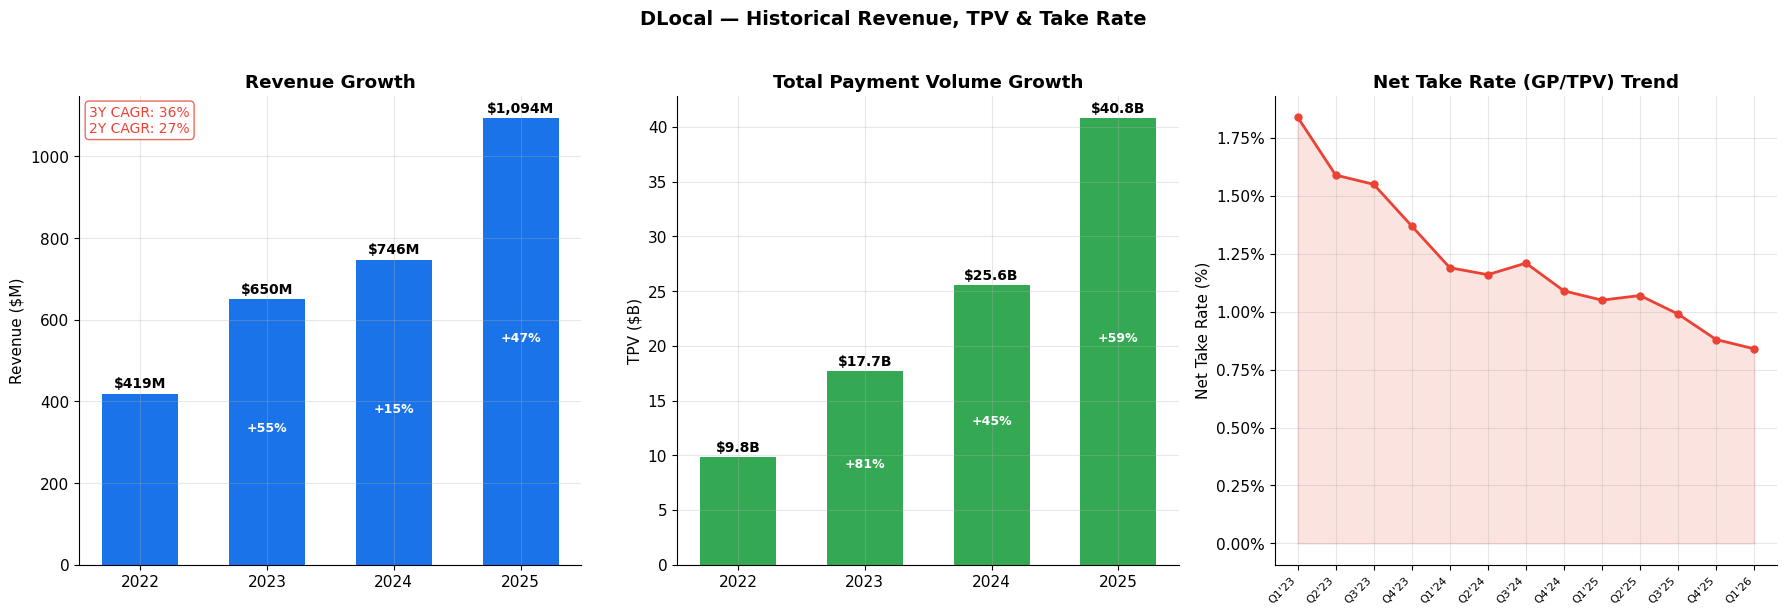

In [8]:
# ============================================================
# CELL GROUP 2: HISTORICAL ANALYSIS — Revenue & Growth
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Revenue growth waterfall
years = income_stmt.index.tolist()
revs = income_stmt['Revenue_M'].values
ax = axes[0]
ax.bar(range(len(years)), revs, color=COLORS['primary'], width=0.6)
for i, (y, r) in enumerate(zip(years, revs)):
    ax.text(i, r + 15, f'${r:,.0f}M', ha='center', fontsize=10, fontweight='bold')
    if i > 0 and not np.isnan(income_stmt['YoY_Growth'].iloc[i]):
        g = income_stmt['YoY_Growth'].iloc[i]
        ax.text(i, r/2, f'+{g:.0%}', ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Revenue Growth', fontweight='bold')

# CAGR
cagr_3yr = (1050 / 419.2) ** (1/3) - 1
cagr_2yr = (1050 / 650.4) ** (1/2) - 1
ax.text(0.02, 0.98, f'3Y CAGR: {cagr_3yr:.0%}\n2Y CAGR: {cagr_2yr:.0%}',
        transform=ax.transAxes, va='top', fontsize=10, color=COLORS['accent'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS['accent'], alpha=0.8))

# 2) TPV growth
ax = axes[1]
tpv_vals = tpv_product['Total_TPV_B'].values
tpv_yrs = tpv_product.index.tolist()
ax.bar(range(len(tpv_yrs)), tpv_vals, color=COLORS['secondary'], width=0.6)
for i, (y, t) in enumerate(zip(tpv_yrs, tpv_vals)):
    ax.text(i, t + 0.5, f'${t:.1f}B', ha='center', fontsize=10, fontweight='bold')
    if i > 0:
        g = tpv_vals[i] / tpv_vals[i-1] - 1
        ax.text(i, t/2, f'+{g:.0%}', ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(range(len(tpv_yrs)))
ax.set_xticklabels(tpv_yrs)
ax.set_ylabel('TPV ($B)')
ax.set_title('Total Payment Volume Growth', fontweight='bold')

# 3) Net take rate trend (quarterly)
ax = axes[2]
qtrs = quarterly_data.index.tolist()
rates = quarterly_data['Net_Take_Rate'].values
ax.plot(range(len(qtrs)), rates, 'o-', color=COLORS['accent'], linewidth=2, markersize=5)
ax.fill_between(range(len(qtrs)), rates, alpha=0.15, color=COLORS['accent'])
ax.set_xticks(range(len(qtrs)))
ax.set_xticklabels(qtrs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Net Take Rate (%)')
ax.set_title('Net Take Rate (GP/TPV) Trend', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

fig.suptitle('DLocal — Historical Revenue, TPV & Take Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

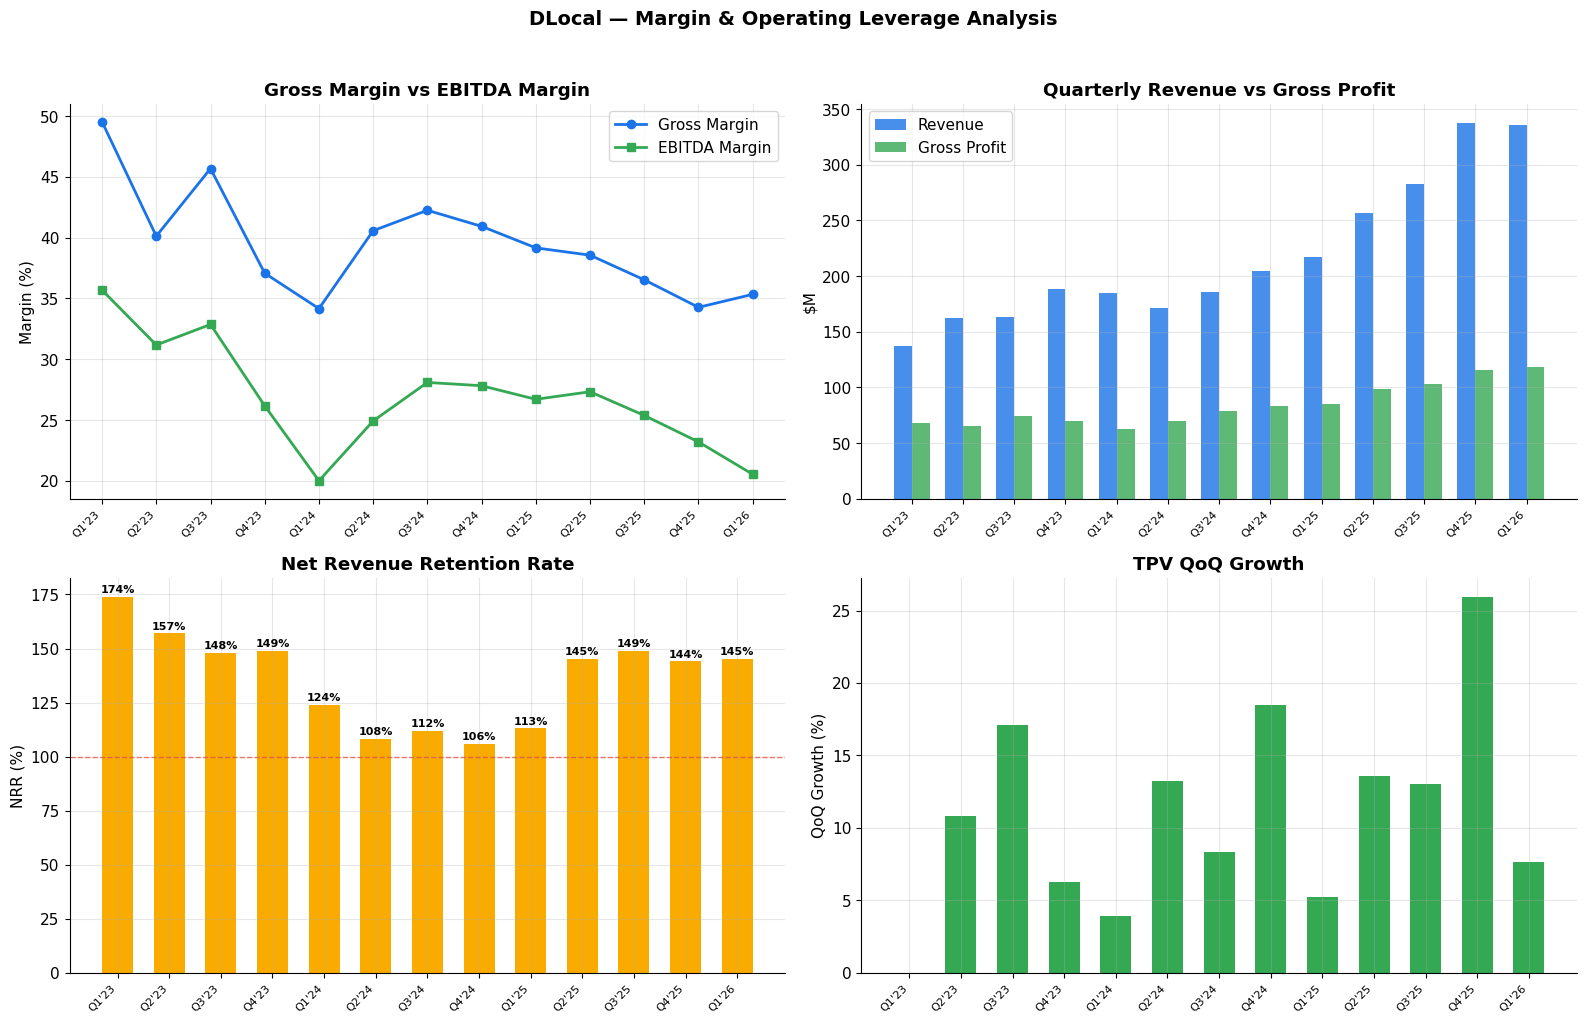

In [9]:
# ── Quarterly Margin & Operating Leverage Analysis ───────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

qtrs = quarterly_data.index.tolist()
x = range(len(qtrs))

# 1) Gross margin vs EBITDA margin
ax = axes[0, 0]
ax.plot(x, quarterly_data['Gross_Margin'], 'o-', color=COLORS['primary'], label='Gross Margin', linewidth=2)
ax.plot(x, quarterly_data['EBITDA_Margin'], 's-', color=COLORS['secondary'], label='EBITDA Margin', linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(qtrs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Margin (%)')
ax.set_title('Gross Margin vs EBITDA Margin', fontweight='bold')
ax.legend()

# 2) Revenue vs GP waterfall quarterly
ax = axes[0, 1]
w = 0.35
ax.bar([i - w/2 for i in x], quarterly_data['Revenue_M'], w, color=COLORS['primary'], label='Revenue', alpha=0.8)
ax.bar([i + w/2 for i in x], quarterly_data['GP_M'], w, color=COLORS['secondary'], label='Gross Profit', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(qtrs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('$M')
ax.set_title('Quarterly Revenue vs Gross Profit', fontweight='bold')
ax.legend()

# 3) NRR trend
ax = axes[1, 0]
ax.bar(x, quarterly_data['NRR'], color=COLORS['gold'], width=0.6)
ax.axhline(y=100, color=COLORS['accent'], linestyle='--', linewidth=1, alpha=0.7)
for i, n in enumerate(quarterly_data['NRR']):
    ax.text(i, n + 2, f'{n:.0f}%', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(qtrs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('NRR (%)')
ax.set_title('Net Revenue Retention Rate', fontweight='bold')

# 4) TPV QoQ growth
ax = axes[1, 1]
tpv_qoq = quarterly_data['TPV_QoQ'].fillna(0).values
colors_bar = [COLORS['secondary'] if v >= 0 else COLORS['accent'] for v in tpv_qoq]
ax.bar(x, tpv_qoq, color=colors_bar, width=0.6)
ax.set_xticks(x)
ax.set_xticklabels(qtrs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('QoQ Growth (%)')
ax.set_title('TPV QoQ Growth', fontweight='bold')

fig.suptitle('DLocal — Margin & Operating Leverage Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

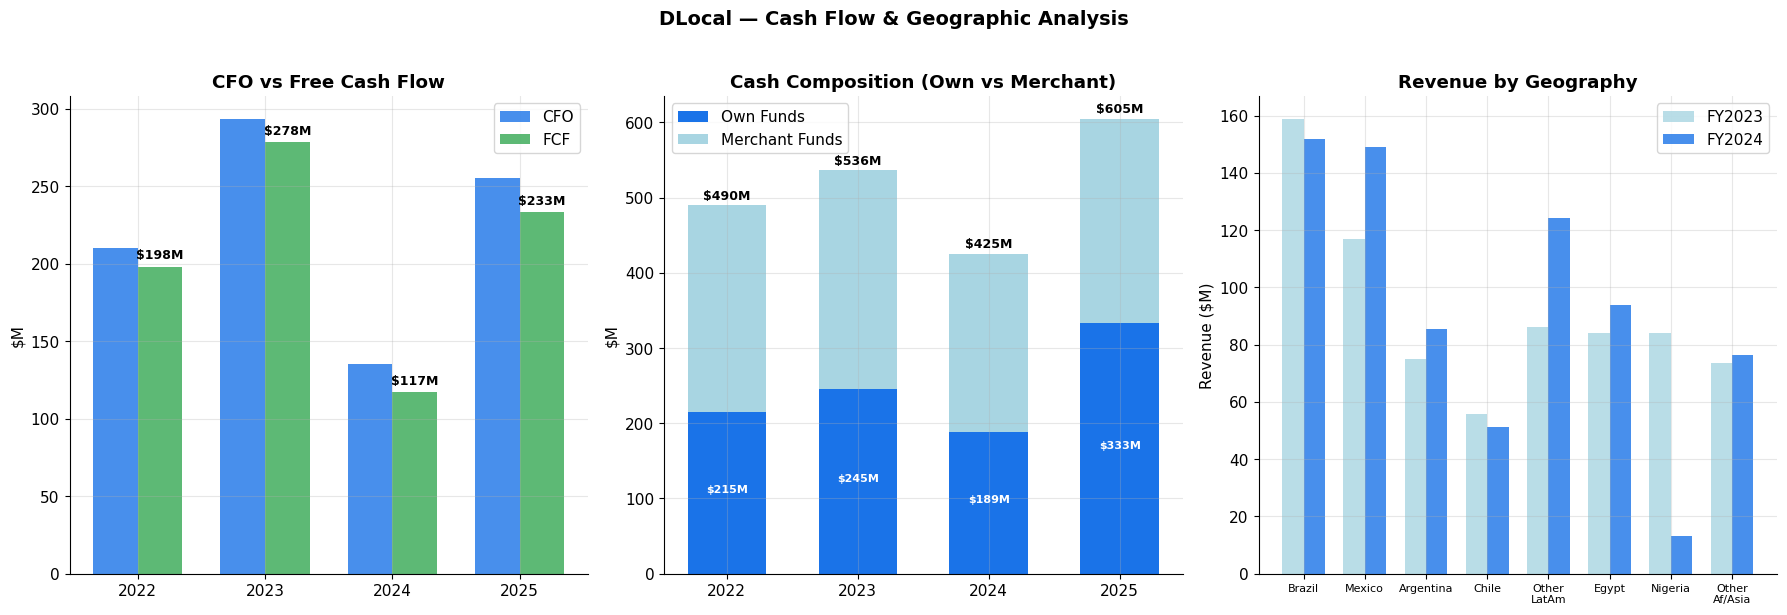

In [10]:
# ── Cash Flow & Balance Sheet Analysis ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

years_cf = cash_flow.index.tolist()

# 1) FCF and CFO
ax = axes[0]
w = 0.35
ax.bar([i - w/2 for i in range(len(years_cf))], cash_flow['CFO'] / 1000, w,
       color=COLORS['primary'], label='CFO', alpha=0.8)
ax.bar([i + w/2 for i in range(len(years_cf))], cash_flow['FCF'] / 1000, w,
       color=COLORS['secondary'], label='FCF', alpha=0.8)
for i, yr in enumerate(years_cf):
    ax.text(i + w/2, cash_flow.loc[yr, 'FCF'] / 1000 + 5,
            f'${cash_flow.loc[yr, "FCF"] / 1000:.0f}M', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(years_cf)))
ax.set_xticklabels(years_cf)
ax.set_ylabel('$M')
ax.set_title('CFO vs Free Cash Flow', fontweight='bold')
ax.legend()

# 2) Own Cash / Corporate Funds
ax = axes[1]
own = balance_sheet['Own_Funds'].values / 1000
merchant = balance_sheet['Merchant_Funds'].values / 1000
bs_yrs = balance_sheet.index.tolist()
ax.bar(range(len(bs_yrs)), own, color=COLORS['primary'], label='Own Funds', width=0.6)
ax.bar(range(len(bs_yrs)), merchant, bottom=own, color=COLORS['light'], label='Merchant Funds', width=0.6)
for i, (o, m) in enumerate(zip(own, merchant)):
    ax.text(i, o + m + 8, f'${o + m:.0f}M', ha='center', fontsize=9, fontweight='bold')
    ax.text(i, o / 2, f'${o:.0f}M', ha='center', fontsize=8, color='white', fontweight='bold')
ax.set_xticks(range(len(bs_yrs)))
ax.set_xticklabels(bs_yrs)
ax.set_ylabel('$M')
ax.set_title('Cash Composition (Own vs Merchant)', fontweight='bold')
ax.legend()

# 3) Geographic revenue mix (2023 vs 2024)
ax = axes[2]
regions = ['Brazil', 'Mexico', 'Argentina', 'Chile', 'Other\nLatAm', 'Egypt', 'Nigeria', 'Other\nAf/Asia']
rev_23 = geo_revenue['FY2023'].values / 1000
rev_24 = geo_revenue['FY2024'].values / 1000
w = 0.35
ax.bar([i - w/2 for i in range(len(regions))], rev_23, w, color=COLORS['light'], label='FY2023', alpha=0.8)
ax.bar([i + w/2 for i in range(len(regions))], rev_24, w, color=COLORS['primary'], label='FY2024', alpha=0.8)
ax.set_xticks(range(len(regions)))
ax.set_xticklabels(regions, fontsize=8)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Revenue by Geography', fontweight='bold')
ax.legend()

fig.suptitle('DLocal — Cash Flow & Geographic Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cell Group 3: Bottom-Up Operating Model (2026-2030)

Three scenarios (Bull, Base, Bear) with different assumptions for TPV growth, net take rates, and operating leverage.

In [11]:
# ============================================================
# CELL GROUP 3: BOTTOM-UP OPERATING MODEL — Assumptions
# ============================================================

proj_years = [2026, 2027, 2028, 2029, 2030]

# Base year (FY2025E)
base_yr = {
    'tpv_b': 40.8,
    'revenue_k': 1_093_600,
    'gross_profit_k': 402_800,
    'adj_ebitda_k': 278_100,
    'net_income_k': 196_900,
    'net_take_rate': 0.99,  # GP/TPV in %
    'gross_margin': 0.368,
    'ebitda_margin': 0.254,
    'opex_k': 176_000,
    'sbc_k': 32_000,
    'da_k': 10_000,
    'cash_k': 451_800,  # corporate cash (Q1'26 actual, was 424,500 FY25)
    'equity_k': 569_400,
    'shares_diluted': 305,  # M
    'capex_k': 22_000,
}

assumptions = {
    'Bull': {
        'tpv_growth':    [0.60, 0.45, 0.35, 0.28, 0.24],
        'net_take_rate': [0.85, 0.82, 0.78, 0.76, 0.75],
        'rev_to_gp':     [0.37, 0.36, 0.35, 0.34, 0.33],
        'ebitda_to_gp':  [0.69, 0.70, 0.71, 0.71, 0.72],   # EBITDA as % of GP
        'sbc_pct_rev':   [0.028, 0.026, 0.024, 0.022, 0.020],
        'tax_rate':      [0.15, 0.15, 0.15, 0.15, 0.15],
        'capex_pct_rev': [0.018, 0.017, 0.016, 0.015, 0.014],
    },
    'Base': {
        'tpv_growth':    [0.55, 0.40, 0.30, 0.25, 0.20],
        'net_take_rate': [0.82, 0.77, 0.72, 0.70, 0.68],
        'rev_to_gp':     [0.35, 0.34, 0.33, 0.32, 0.31],
        'ebitda_to_gp':  [0.69, 0.69, 0.69, 0.69, 0.69],   # flat per user guidance
        'sbc_pct_rev':   [0.030, 0.028, 0.026, 0.025, 0.024],
        'tax_rate':      [0.15, 0.15, 0.15, 0.15, 0.15],
        'capex_pct_rev': [0.018, 0.017, 0.016, 0.016, 0.015],
    },
    'Bear': {
        'tpv_growth':    [0.45, 0.30, 0.22, 0.18, 0.15],
        'net_take_rate': [0.75, 0.70, 0.66, 0.63, 0.61],
        'rev_to_gp':     [0.33, 0.31, 0.30, 0.29, 0.28],
        'ebitda_to_gp':  [0.65, 0.65, 0.64, 0.64, 0.63],   # slight deterioration
        'sbc_pct_rev':   [0.032, 0.030, 0.028, 0.027, 0.026],
        'tax_rate':      [0.15, 0.15, 0.15, 0.15, 0.15],
        'capex_pct_rev': [0.020, 0.019, 0.018, 0.018, 0.017],
    },
}

# Display assumptions
for scenario in ['Bull', 'Base', 'Bear']:
    a = assumptions[scenario]
    print(f'\n{"=" * 55}')
    print(f'  {scenario.upper()} CASE ASSUMPTIONS')
    print(f'{"=" * 55}')
    df_a = pd.DataFrame({
        'TPV Growth': [f'{x:.0%}' for x in a['tpv_growth']],
        'Net Take Rate': [f'{x:.2f}%' for x in a['net_take_rate']],
        'Gross Margin': [f'{x:.0%}' for x in a['rev_to_gp']],
        'EBITDA/GP': [f'{x:.0%}' for x in a['ebitda_to_gp']],
        'SBC % Rev': [f'{x:.1%}' for x in a['sbc_pct_rev']],
        'Tax Rate': [f'{x:.0%}' for x in a['tax_rate']],
    }, index=proj_years)
    print(df_a.to_string())


  BULL CASE ASSUMPTIONS
     TPV Growth Net Take Rate Gross Margin EBITDA/GP SBC % Rev Tax Rate
2026        60%         0.85%          37%       69%      2.8%      15%
2027        45%         0.82%          36%       70%      2.6%      15%
2028        35%         0.78%          35%       71%      2.4%      15%
2029        28%         0.76%          34%       71%      2.2%      15%
2030        24%         0.75%          33%       72%      2.0%      15%

  BASE CASE ASSUMPTIONS
     TPV Growth Net Take Rate Gross Margin EBITDA/GP SBC % Rev Tax Rate
2026        55%         0.82%          35%       69%      3.0%      15%
2027        40%         0.77%          34%       69%      2.8%      15%
2028        30%         0.72%          33%       69%      2.6%      15%
2029        25%         0.70%          32%       69%      2.5%      15%
2030        20%         0.68%          31%       69%      2.4%      15%

  BEAR CASE ASSUMPTIONS
     TPV Growth Net Take Rate Gross Margin EBITDA/GP SBC % Re

In [12]:
# ── Build Bottom-Up Projections for All Scenarios ────────────

def build_projection(scenario_name, assumptions):
    # Shares held flat at 305M — buyback program (~$300M authorized)
    # assumed to roughly offset SBC dilution, so no net dilution modeled.
    a = assumptions
    rows = []
    prev_tpv = base_yr['tpv_b']

    for i, yr in enumerate(proj_years):
        # TPV
        tpv = prev_tpv * (1 + a['tpv_growth'][i])

        # Gross profit from TPV * net take rate
        gp = tpv * 1e9 * (a['net_take_rate'][i] / 100)  # in $
        gp_k = gp / 1000  # in $K

        # Revenue implied from GP and gross margin
        rev_k = gp_k / a['rev_to_gp'][i]

        # Cost of services
        cos_k = rev_k - gp_k

        # EBITDA from GP ratio, then back-solve OpEx
        adj_ebitda_k = gp_k * a['ebitda_to_gp'][i]
        opex_k = gp_k - adj_ebitda_k

        # SBC
        sbc_k = rev_k * a['sbc_pct_rev'][i]

        # D&A (grows slowly)
        da_k = base_yr['da_k'] * (1.08 ** (i + 1))

        # Operating income (GAAP) = GP - OpEx - SBC - D&A
        op_income_k = gp_k - opex_k - sbc_k - da_k

        # Pre-tax income (add small other income)
        other_income_k = rev_k * 0.005  # ~0.5% of rev
        pretax_k = op_income_k + other_income_k

        # Net income
        tax_k = pretax_k * a['tax_rate'][i]
        ni_k = pretax_k - tax_k

        # Capex
        capex_k = rev_k * a['capex_pct_rev'][i]

        # FCF
        cfo_k = ni_k + da_k + sbc_k  # simplified CFO
        fcf_k = cfo_k - capex_k

        dividend_k = fcf_k * 0.30  # 30% of FCF returned as dividends

        rows.append({
            'Year': yr,
            'TPV_B': tpv,
            'Revenue': rev_k,
            'Cost_of_Services': -cos_k,
            'Gross_Profit': gp_k,
            'Gross_Margin': a['rev_to_gp'][i],
            'OpEx': -opex_k,
            'SBC': -sbc_k,
            'DA': -da_k,
            'Operating_Income': op_income_k,
            'Adj_EBITDA': adj_ebitda_k,
            'EBITDA_Margin': adj_ebitda_k / rev_k,
            'Net_Income': ni_k,
            'Net_Margin': ni_k / rev_k,
            'Capex': -capex_k,
            'FCF': fcf_k,
            'Net_Take_Rate': a['net_take_rate'][i],
            'Total_Revenue': rev_k,  # alias for consistency
            'Dividend_K': dividend_k,
            'FCF_After_Div': fcf_k - dividend_k,
        })

        prev_tpv = tpv

    return pd.DataFrame(rows).set_index('Year')

# Build all three
projections = {}
for scenario in ['Bull', 'Base', 'Bear']:
    projections[scenario] = build_projection(scenario, assumptions[scenario])

# Display
for scenario in ['Bull', 'Base', 'Bear']:
    p = projections[scenario]
    print(f'\n{"=" * 65}')
    print(f'  {scenario.upper()} CASE PROJECTIONS')
    print(f'{"=" * 65}')
    display_df = p[['TPV_B', 'Revenue', 'Gross_Profit', 'Adj_EBITDA', 'Net_Income', 'FCF']].copy()
    display_df['Rev_M'] = display_df['Revenue'] / 1000
    display_df['GP_M'] = display_df['Gross_Profit'] / 1000
    display_df['EBITDA_M'] = display_df['Adj_EBITDA'] / 1000
    display_df['NI_M'] = display_df['Net_Income'] / 1000
    display_df['FCF_M'] = display_df['FCF'] / 1000
    print(display_df[['TPV_B', 'Rev_M', 'GP_M', 'EBITDA_M', 'NI_M', 'FCF_M']].to_string(
        float_format=lambda x: f'{x:,.1f}'))
    print(f'\n  Rev CAGR (2025-2030): {(p.loc[2030, "Revenue"] / base_yr["revenue_k"]) ** (1/5) - 1:.1%}')
    print(f'  2030 EBITDA Margin: {p.loc[2030, "EBITDA_Margin"]:.1%}')

# ── Phase 2: Fade Period (2031-2035) ────────────────────────
# Simplified model bridging from Phase 1 growth to terminal state.
# TPV growth decelerates, take rates stabilize near a floor,
# EBITDA/GP holds at scenario-specific levels.

fade_years = [2031, 2032, 2033, 2034, 2035]

fade_assumptions = {
    'Bull': {
        'tpv_growth':    [0.20, 0.17, 0.14, 0.12, 0.10],
        'net_take_rate': [0.73, 0.72, 0.71, 0.70, 0.70],
        'gross_margin':  [0.32, 0.32, 0.31, 0.31, 0.31],
        'ebitda_to_gp':  [0.72, 0.72, 0.73, 0.73, 0.73],
        'sbc_pct_rev':   0.020,
        'tax_rate':      0.15,
        'capex_pct_rev': 0.014,
    },
    'Base': {
        'tpv_growth':    [0.17, 0.14, 0.12, 0.10, 0.08],
        'net_take_rate': [0.66, 0.65, 0.64, 0.63, 0.63],
        'gross_margin':  [0.31, 0.30, 0.30, 0.30, 0.30],
        'ebitda_to_gp':  [0.69, 0.69, 0.69, 0.69, 0.69],
        'sbc_pct_rev':   0.024,
        'tax_rate':      0.15,
        'capex_pct_rev': 0.015,
    },
    'Bear': {
        'tpv_growth':    [0.12, 0.10, 0.08, 0.07, 0.06],
        'net_take_rate': [0.60, 0.59, 0.58, 0.58, 0.58],
        'gross_margin':  [0.28, 0.27, 0.27, 0.27, 0.27],
        'ebitda_to_gp':  [0.63, 0.62, 0.62, 0.62, 0.62],
        'sbc_pct_rev':   0.026,
        'tax_rate':      0.15,
        'capex_pct_rev': 0.017,
    },
}

fade_projections = {}

for scenario in ['Bull', 'Base', 'Bear']:
    fa = fade_assumptions[scenario]
    p1 = projections[scenario]
    rows = []
    prev_tpv = p1.loc[2030, 'TPV_B']

    for i, yr in enumerate(fade_years):
        tpv = prev_tpv * (1 + fa['tpv_growth'][i])
        gp_k = tpv * 1e9 * (fa['net_take_rate'][i] / 100) / 1000
        rev_k = gp_k / fa['gross_margin'][i]
        adj_ebitda_k = gp_k * fa['ebitda_to_gp'][i]
        opex_k = gp_k - adj_ebitda_k
        sbc_k = rev_k * fa['sbc_pct_rev']
        da_k = base_yr['da_k'] * (1.08 ** (5 + i + 1))  # continues from Phase 1
        op_income_k = gp_k - opex_k - sbc_k - da_k
        other_income_k = rev_k * 0.005
        pretax_k = op_income_k + other_income_k
        tax_k = pretax_k * fa['tax_rate']
        ni_k = pretax_k - tax_k
        capex_k = rev_k * fa['capex_pct_rev']
        cfo_k = ni_k + da_k + sbc_k
        fcf_k = cfo_k - capex_k
        dividend_k = fcf_k * 0.30

        rows.append({
            'Year': yr,
            'TPV_B': tpv,
            'Revenue': rev_k,
            'Gross_Profit': gp_k,
            'Gross_Margin': fa['gross_margin'][i],
            'Adj_EBITDA': adj_ebitda_k,
            'EBITDA_Margin': adj_ebitda_k / rev_k,
            'EBITDA_to_GP': fa['ebitda_to_gp'][i],
            'Net_Income': ni_k,
            'Capex': -capex_k,
            'FCF': fcf_k,
            'Dividend_K': dividend_k,
            'FCF_After_Div': fcf_k - dividend_k,
            'Net_Take_Rate': fa['net_take_rate'][i],
            'OpEx': -opex_k,
            'SBC': -sbc_k,
            'DA': -da_k,
            'Operating_Income': op_income_k,
        })
        prev_tpv = tpv

    fade_projections[scenario] = pd.DataFrame(rows).set_index('Year')

# Display Base case fade
print('\n' + '=' * 65)
print('  BASE CASE FADE PERIOD (2031-2035)')
print('=' * 65)
fb = fade_projections['Base']
display_fb = fb[['TPV_B', 'Revenue', 'Gross_Profit', 'Adj_EBITDA', 'Net_Income', 'FCF']].copy()
display_fb['Rev_M'] = display_fb['Revenue'] / 1000
display_fb['GP_M'] = display_fb['Gross_Profit'] / 1000
display_fb['EBITDA_M'] = display_fb['Adj_EBITDA'] / 1000
display_fb['FCF_M'] = display_fb['FCF'] / 1000
display_fb['EBITDA/GP'] = fb['EBITDA_to_GP']
print(display_fb[['TPV_B', 'Rev_M', 'GP_M', 'EBITDA_M', 'FCF_M', 'EBITDA/GP']].to_string(
    float_format=lambda x: f'{x:,.1f}' if abs(x) > 1 else f'{x:.0%}'))
print(f'\n  Rev CAGR (2030-2035): {(fb.loc[2035, "Revenue"] / projections["Base"].loc[2030, "Revenue"]) ** (1/5) - 1:.1%}')



  BULL CASE PROJECTIONS
      TPV_B   Rev_M    GP_M  EBITDA_M  NI_M  FCF_M
Year                                              
2026   65.3 1,499.7   554.9     382.9 286.9  312.7
2027   94.7 2,156.1   776.2     543.3 413.4  444.5
2028  127.8 2,847.8   996.7     707.7 544.8  580.2
2029  163.6 3,656.2 1,243.1     882.6 685.8  725.0
2030  202.8 4,609.6 1,521.2   1,095.2 859.7  902.0

  Rev CAGR (2025-2030): 33.3%
  2030 EBITDA Margin: 23.8%

  BASE CASE PROJECTIONS
      TPV_B   Rev_M    GP_M  EBITDA_M  NI_M  FCF_M
Year                                              
2026   63.2 1,481.6   518.6     357.8 263.5  292.1
2027   88.5 2,005.1   681.7     470.4 350.7  384.4
2028  115.1 2,511.2   828.7     571.8 430.5  468.2
2029  143.9 3,147.2 1,007.1     694.9 525.6  567.5
2030  172.6 3,787.1 1,174.0     810.1 614.9  663.7

  Rev CAGR (2025-2030): 28.2%
  2030 EBITDA Margin: 21.4%

  BEAR CASE PROJECTIONS
      TPV_B   Rev_M  GP_M  EBITDA_M  NI_M  FCF_M
Year                                        

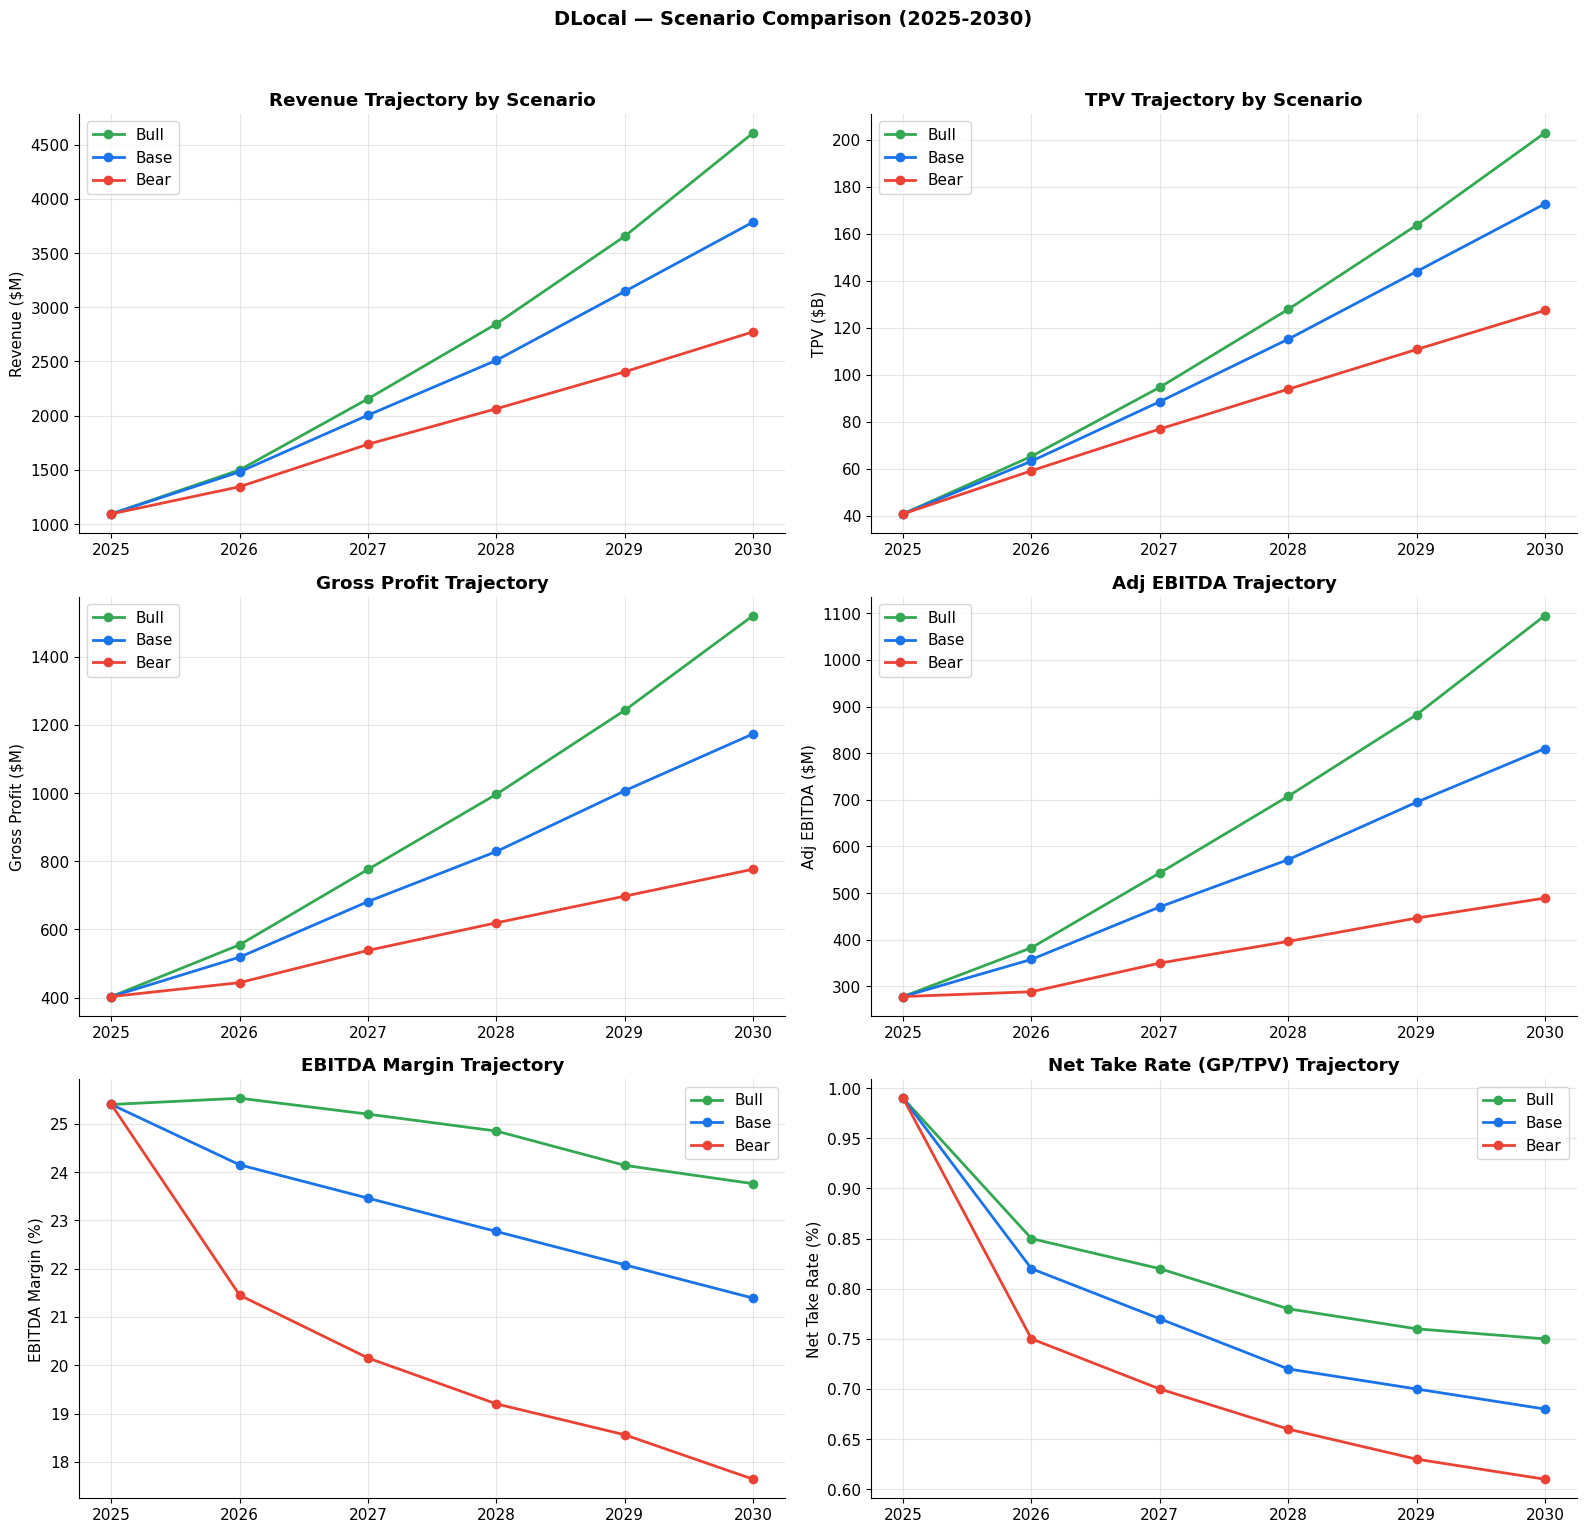

In [13]:
# ── Scenario Comparison Charts ───────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
scenario_colors = {'Bull': COLORS['secondary'], 'Base': COLORS['primary'], 'Bear': COLORS['accent']}

# Add base year for continuity
all_years = [2025] + proj_years

# 1) Revenue path
ax = axes[0, 0]
for s in ['Bull', 'Base', 'Bear']:
    rev_path = [base_yr['revenue_k'] / 1000] + [projections[s].loc[y, 'Revenue'] / 1000 for y in proj_years]
    ax.plot(range(len(all_years)), rev_path, 'o-', color=scenario_colors[s], label=s, linewidth=2)
ax.set_xticks(range(len(all_years)))
ax.set_xticklabels(all_years)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Revenue Trajectory by Scenario', fontweight='bold')
ax.legend()

# 2) TPV path
ax = axes[0, 1]
for s in ['Bull', 'Base', 'Bear']:
    tpv_path = [base_yr['tpv_b']] + [projections[s].loc[y, 'TPV_B'] for y in proj_years]
    ax.plot(range(len(all_years)), tpv_path, 'o-', color=scenario_colors[s], label=s, linewidth=2)
ax.set_xticks(range(len(all_years)))
ax.set_xticklabels(all_years)
ax.set_ylabel('TPV ($B)')
ax.set_title('TPV Trajectory by Scenario', fontweight='bold')
ax.legend()

# 3) Gross Profit
ax = axes[1, 0]
for s in ['Bull', 'Base', 'Bear']:
    gp_path = [base_yr['gross_profit_k'] / 1000] + [projections[s].loc[y, 'Gross_Profit'] / 1000 for y in proj_years]
    ax.plot(range(len(all_years)), gp_path, 'o-', color=scenario_colors[s], label=s, linewidth=2)
ax.set_xticks(range(len(all_years)))
ax.set_xticklabels(all_years)
ax.set_ylabel('Gross Profit ($M)')
ax.set_title('Gross Profit Trajectory', fontweight='bold')
ax.legend()

# 4) EBITDA
ax = axes[1, 1]
for s in ['Bull', 'Base', 'Bear']:
    ebitda_path = [base_yr['adj_ebitda_k'] / 1000] + [projections[s].loc[y, 'Adj_EBITDA'] / 1000 for y in proj_years]
    ax.plot(range(len(all_years)), ebitda_path, 'o-', color=scenario_colors[s], label=s, linewidth=2)
ax.set_xticks(range(len(all_years)))
ax.set_xticklabels(all_years)
ax.set_ylabel('Adj EBITDA ($M)')
ax.set_title('Adj EBITDA Trajectory', fontweight='bold')
ax.legend()

# 5) EBITDA Margin
ax = axes[2, 0]
for s in ['Bull', 'Base', 'Bear']:
    margin_path = [base_yr['ebitda_margin']] + [projections[s].loc[y, 'EBITDA_Margin'] for y in proj_years]
    ax.plot(range(len(all_years)), [m * 100 for m in margin_path], 'o-', color=scenario_colors[s], label=s, linewidth=2)
ax.set_xticks(range(len(all_years)))
ax.set_xticklabels(all_years)
ax.set_ylabel('EBITDA Margin (%)')
ax.set_title('EBITDA Margin Trajectory', fontweight='bold')
ax.legend()

# 6) Net Take Rate
ax = axes[2, 1]
for s in ['Bull', 'Base', 'Bear']:
    ntr_path = [base_yr['net_take_rate']] + [projections[s].loc[y, 'Net_Take_Rate'] for y in proj_years]
    ax.plot(range(len(all_years)), ntr_path, 'o-', color=scenario_colors[s], label=s, linewidth=2)
ax.set_xticks(range(len(all_years)))
ax.set_xticklabels(all_years)
ax.set_ylabel('Net Take Rate (%)')
ax.set_title('Net Take Rate (GP/TPV) Trajectory', fontweight='bold')
ax.legend()

fig.suptitle('DLocal — Scenario Comparison (2025-2030)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# ── Geographic Growth Matrix ─────────────────────────────────

print('══════════════════════════════════════════════════════════════')
print('  GEOGRAPHIC GROWTH MATRIX — BASE CASE')
print('══════════════════════════════════════════════════════════════')

# Regional TPV growth assumptions (Base case)
geo_assumptions = {
    'LatAm': {
        'tpv_2025_b': 26.0,  # ~68% of total
        'growth': [0.30, 0.24, 0.20, 0.18, 0.16],
        'take_rate': [1.05, 1.00, 0.96, 0.94, 0.93],
    },
    'Africa_Asia': {
        'tpv_2025_b': 12.0,  # ~32% of total
        'growth': [0.45, 0.38, 0.30, 0.25, 0.22],
        'take_rate': [0.85, 0.82, 0.78, 0.75, 0.74],
    },
}

print(f'{"Year":<8}', end='')
for yr in proj_years:
    print(f'{yr:>10}', end='')
print()
print('-' * 58)

total_tpv = []
total_gp = []

for region, ga in geo_assumptions.items():
    tpv_r = ga['tpv_2025_b']
    tpvs = []
    gps = []
    for i in range(5):
        tpv_r *= (1 + ga['growth'][i])
        gp_r = tpv_r * ga['take_rate'][i] / 100
        tpvs.append(tpv_r)
        gps.append(gp_r)

    print(f'\n  {region}:')
    print(f'{"  TPV ($B)":<8}', end='')
    for t in tpvs:
        print(f'  ${t:>6.1f}B', end='')
    print()
    print(f'{"  Growth":<8}', end='')
    for g in ga['growth']:
        print(f'  {g:>7.0%}', end='')
    print()
    print(f'{"  Take Rate":<8}', end='')
    for tr in ga['take_rate']:
        print(f'  {tr:>6.2f}%', end='')
    print()
    print(f'{"  GP ($M)":<8}', end='')
    for g in gps:
        print(f'  ${g*1000:>6.0f}M', end='')
    print()

    if not total_tpv:
        total_tpv = tpvs[:]
        total_gp = gps[:]
    else:
        total_tpv = [a + b for a, b in zip(total_tpv, tpvs)]
        total_gp = [a + b for a, b in zip(total_gp, gps)]

print(f'\n  TOTAL:')
print(f'{"  TPV ($B)":<8}', end='')
for t in total_tpv:
    print(f'  ${t:>6.1f}B', end='')
print()
print(f'{"  GP ($M)":<8}', end='')
for g in total_gp:
    print(f'  ${g*1000:>6.0f}M', end='')
print()

# Geographic mix shift
print('\n\n── Africa/Asia Share of TPV ──')
for i, yr in enumerate(proj_years):
    aa_pct = (total_tpv[i] - [ga['tpv_2025_b'] for ga in [geo_assumptions['LatAm']]][0] *
              np.prod([1 + g for g in geo_assumptions['LatAm']['growth'][:i+1]])) / total_tpv[i]
    print(f'  {yr}: LatAm share declining as Africa/Asia grows faster')

print('\nKey insight: Africa/Asia grows faster (~30-45% CAGR vs ~16-30% LatAm)')
print('but LatAm maintains higher absolute GP contribution due to better take rates.')

══════════════════════════════════════════════════════════════
  GEOGRAPHIC GROWTH MATRIX — BASE CASE
══════════════════════════════════════════════════════════════
Year          2026      2027      2028      2029      2030
----------------------------------------------------------

  LatAm:
  TPV ($B)  $  33.8B  $  41.9B  $  50.3B  $  59.3B  $  68.8B
  Growth      30%      24%      20%      18%      16%
  Take Rate    1.05%    1.00%    0.96%    0.94%    0.93%
  GP ($M)  $   355M  $   419M  $   483M  $   558M  $   640M

  Africa_Asia:
  TPV ($B)  $  17.4B  $  24.0B  $  31.2B  $  39.0B  $  47.6B
  Growth      45%      38%      30%      25%      22%
  Take Rate    0.85%    0.82%    0.78%    0.75%    0.74%
  GP ($M)  $   148M  $   197M  $   243M  $   293M  $   352M

  TOTAL:
  TPV ($B)  $  51.2B  $  65.9B  $  81.5B  $  98.4B  $ 116.4B
  GP ($M)  $   503M  $   616M  $   726M  $   851M  $   993M


── Africa/Asia Share of TPV ──
  2026: LatAm share declining as Africa/Asia grows faster
  202

# Cell Group 4: 3-Statement Projected Model (2026-2030)

Full income statement, balance sheet, and cash flow projections using the Base case operating model assumptions.

In [15]:
# ============================================================
# CELL GROUP 4: 3-STATEMENT MODEL (Base Case)
# ============================================================

p = projections['Base']

# ── Income Statement ──
is_proj = pd.DataFrame(index=proj_years)
is_proj['Revenue'] = p['Revenue']
is_proj['Cost_of_Services'] = p['Cost_of_Services']
is_proj['Gross_Profit'] = p['Gross_Profit']
is_proj['Gross_Margin'] = p['Gross_Margin']
is_proj['OpEx'] = p['OpEx']
is_proj['SBC'] = p['SBC']
is_proj['DA'] = p['DA']
is_proj['Operating_Income'] = p['Operating_Income']
is_proj['Other_Income'] = p['Revenue'] * 0.005
is_proj['Pretax_Income'] = is_proj['Operating_Income'] + is_proj['Other_Income']
is_proj['Tax'] = -is_proj['Pretax_Income'] * 0.15
is_proj['Net_Income'] = p['Net_Income']
is_proj['Adj_EBITDA'] = p['Adj_EBITDA']
is_proj['EBITDA_Margin'] = p['EBITDA_Margin']

print('══════════════════════════════════════════════════════════════')
print('  PROJECTED INCOME STATEMENT — BASE CASE ($K)')
print('══════════════════════════════════════════════════════════════')

for yr in proj_years:
    print(f'\n  ── {yr} ──')
    print(f'  Revenue:              ${is_proj.loc[yr, "Revenue"]:>12,.0f}')
    print(f'  Cost of Services:     ${is_proj.loc[yr, "Cost_of_Services"]:>12,.0f}')
    print(f'  Gross Profit:         ${is_proj.loc[yr, "Gross_Profit"]:>12,.0f}  ({is_proj.loc[yr, "Gross_Margin"]:.1%})')
    print(f'  Operating Expenses:   ${is_proj.loc[yr, "OpEx"]:>12,.0f}')
    print(f'  SBC:                  ${is_proj.loc[yr, "SBC"]:>12,.0f}')
    print(f'  D&A:                  ${is_proj.loc[yr, "DA"]:>12,.0f}')
    print(f'  Operating Income:     ${is_proj.loc[yr, "Operating_Income"]:>12,.0f}')
    print(f'  Pretax Income:        ${is_proj.loc[yr, "Pretax_Income"]:>12,.0f}')
    print(f'  Net Income:           ${is_proj.loc[yr, "Net_Income"]:>12,.0f}')
    print(f'  Adj EBITDA:           ${is_proj.loc[yr, "Adj_EBITDA"]:>12,.0f}  ({is_proj.loc[yr, "EBITDA_Margin"]:.1%})')

# ── Balance Sheet (simplified) ──
bs_proj = pd.DataFrame(index=proj_years)
prev_cash = base_yr['cash_k']
prev_equity = base_yr['equity_k']

for yr in proj_years:
    rev = is_proj.loc[yr, 'Revenue']
    ni = is_proj.loc[yr, 'Net_Income']
    sbc = abs(is_proj.loc[yr, 'SBC'])
    da = abs(is_proj.loc[yr, 'DA'])
    capex = abs(p.loc[yr, 'Capex'])

    # Simplified CFO = NI + D&A + SBC + WC changes (assume flat)
    cfo = ni + da + sbc
    fcf = cfo - capex
    dividend = p.loc[yr, 'Dividend_K'] if 'Dividend_K' in p.columns else fcf * 0.30

    cash = prev_cash + fcf - dividend
    equity = prev_equity + ni + sbc - dividend  # equity grows by NI + SBC - dividends

    bs_proj.loc[yr, 'Cash'] = cash
    bs_proj.loc[yr, 'Total_Assets'] = cash + rev * 0.55  # rough proxy
    bs_proj.loc[yr, 'Total_Equity'] = equity
    bs_proj.loc[yr, 'Total_Liabilities'] = bs_proj.loc[yr, 'Total_Assets'] - equity
    bs_proj.loc[yr, 'FCF'] = fcf
    bs_proj.loc[yr, 'CFO'] = cfo
    bs_proj.loc[yr, 'Capex'] = -capex
    bs_proj.loc[yr, 'Dividends'] = -dividend

    prev_cash = cash
    prev_equity = equity

print('\n\n══════════════════════════════════════════════════════════════')
print('  PROJECTED BALANCE SHEET SUMMARY — BASE CASE ($K)')
print('══════════════════════════════════════════════════════════════')
print(bs_proj[['Cash', 'Total_Assets', 'Total_Equity', 'Total_Liabilities']].to_string(
    float_format=lambda x: f'{x:,.0f}'))

══════════════════════════════════════════════════════════════
  PROJECTED INCOME STATEMENT — BASE CASE ($K)
══════════════════════════════════════════════════════════════

  ── 2026 ──
  Revenue:              $   1,481,623
  Cost of Services:     $    -963,055
  Gross Profit:         $     518,568  (35.0%)
  Operating Expenses:   $    -160,756
  SBC:                  $     -44,449
  D&A:                  $     -10,800
  Operating Income:     $     302,563
  Pretax Income:        $     309,971
  Net Income:           $     263,476
  Adj EBITDA:           $     357,812  (24.1%)

  ── 2027 ──
  Revenue:              $   2,005,080
  Cost of Services:     $  -1,323,353
  Gross Profit:         $     681,727  (34.0%)
  Operating Expenses:   $    -211,335
  SBC:                  $     -56,142
  D&A:                  $     -11,664
  Operating Income:     $     402,586
  Pretax Income:        $     412,611
  Net Income:           $     350,719
  Adj EBITDA:           $     470,392  (23.5%)

  ─

In [16]:
# ── Balance Sheet & Cash Flow Display + Verification ─────────

print('══════════════════════════════════════════════════════════════')
print('  PROJECTED CASH FLOW — BASE CASE ($K)')
print('══════════════════════════════════════════════════════════════')
print(bs_proj[['CFO', 'Capex', 'FCF', 'Dividends', 'Cash']].to_string(
    float_format=lambda x: f'{x:,.0f}'))

print('\n\n── Verification Checks ──')
for yr in proj_years:
    assets = bs_proj.loc[yr, 'Total_Assets']
    liab_eq = bs_proj.loc[yr, 'Total_Liabilities'] + bs_proj.loc[yr, 'Total_Equity']
    balanced = abs(assets - liab_eq) < 1
    print(f'  {yr}: Assets={assets:,.0f} | Liab+Eq={liab_eq:,.0f} | '
          f'Balanced={"YES" if balanced else "NO"}')

# FCF conversion check
print('\n── FCF Conversion & Margins ──')
for yr in proj_years:
    fcf = bs_proj.loc[yr, 'FCF']
    ni = is_proj.loc[yr, 'Net_Income']
    rev = is_proj.loc[yr, 'Revenue']
    print(f'  {yr}: FCF/NI = {fcf/ni:.0%} | FCF Margin = {fcf/rev:.1%} | '
          f'FCF = ${fcf/1000:,.0f}M')

══════════════════════════════════════════════════════════════
  PROJECTED CASH FLOW — BASE CASE ($K)
══════════════════════════════════════════════════════════════
         CFO   Capex     FCF  Dividends      Cash
2026 318,724 -26,669 292,055    -87,617   656,239
2027 418,526 -34,086 384,439   -115,332   925,346
2028 508,387 -40,179 468,207   -140,462 1,253,091
2029 617,881 -50,355 567,526   -170,258 1,650,359
2030 720,476 -56,806 663,670   -199,101 2,114,928


── Verification Checks ──
  2026: Assets=1,471,131 | Liab+Eq=1,471,131 | Balanced=YES
  2027: Assets=2,028,140 | Liab+Eq=2,028,140 | Balanced=YES
  2028: Assets=2,634,253 | Liab+Eq=2,634,253 | Balanced=YES
  2029: Assets=3,381,307 | Liab+Eq=3,381,307 | Balanced=YES
  2030: Assets=4,197,809 | Liab+Eq=4,197,809 | Balanced=YES

── FCF Conversion & Margins ──
  2026: FCF/NI = 111% | FCF Margin = 19.7% | FCF = $292M
  2027: FCF/NI = 110% | FCF Margin = 19.2% | FCF = $384M
  2028: FCF/NI = 109% | FCF Margin = 18.6% | FCF = $468M
  20

# Cell Group 5: DCF Valuation

Discounted Cash Flow valuation using unlevered free cash flow, CAPM-derived cost of equity (minimal debt), and Gordon Growth terminal value.

In [17]:
# ============================================================
# CELL GROUP 5: DCF VALUATION (10-YEAR MODEL)
# ============================================================

def run_dcf(proj_df, fade_df, scenario_name='Base',
            risk_free=0.043, beta=1.30, erp=0.055, terminal_growth=0.035,
            net_cash_k=451_800, shares_m=305):
    """
    10-Year DCF valuation using:
    - Phase 1 (2026-2030): detailed bottom-up projections
    - Phase 2 (2031-2035): fade period bridging to terminal state
    - CAPM cost of equity (minimal debt -> WACC ~ cost of equity)
    - FCF = Adj EBITDA - cash taxes - capex - WC changes
    - Gordon Growth terminal value at year 10
    - Shares kept flat at 305M (buyback program offsets SBC dilution)
    """

    cost_of_equity = risk_free + beta * erp
    wacc = cost_of_equity

    print(f'\n{"=" * 60}')
    print(f'  10-YEAR DCF VALUATION — {scenario_name.upper()} CASE')
    print(f'{"=" * 60}')
    print(f'\n  WACC Calculation:')
    print(f'    Risk-free rate:      {risk_free:.1%}')
    print(f'    Beta:                {beta:.2f}')
    print(f'    Equity risk premium: {erp:.1%}')
    print(f'    Cost of equity:      {cost_of_equity:.1%}')
    print(f'    WACC:                {wacc:.1%}')
    print(f'    Terminal growth:     {terminal_growth:.1%}')

    all_years = list(proj_df.index) + list(fade_df.index)

    fcfs = []
    print(f'\n  {"Year":<8}{"EBITDA":>12}{"Taxes":>12}{"Capex":>12}{"WC Chg":>12}{"FCF":>12}{"Phase":>8}')
    print(f'  {"-"*72}')

    for yr in all_years:
        if yr in proj_df.index:
            df = proj_df
            phase = 'Detail'
        else:
            df = fade_df
            phase = 'Fade'
        ebitda = df.loc[yr, 'Adj_EBITDA']
        taxes = ebitda * 0.15
        capex = abs(df.loc[yr, 'Capex'])
        wc_chg = df.loc[yr, 'Revenue'] * 0.01
        fcf = ebitda - taxes - capex - wc_chg
        fcfs.append(fcf)
        print(f'  {yr:<8}${ebitda/1000:>10,.0f}M  -${taxes/1000:>9,.0f}M  -${capex/1000:>9,.0f}M  -${wc_chg/1000:>9,.0f}M  ${fcf/1000:>10,.0f}M  {phase:>6}')

    # Discount FCFs
    pv_fcfs = sum(fcf / (1 + wacc) ** (i + 1) for i, fcf in enumerate(fcfs))

    # Terminal value at year 10
    terminal_fcf = fcfs[-1] * (1 + terminal_growth)
    tv = terminal_fcf / (wacc - terminal_growth)
    pv_tv = tv / (1 + wacc) ** len(all_years)

    ev = pv_fcfs + pv_tv
    equity_value = ev + net_cash_k
    diluted_shares = shares_m
    price_diluted = equity_value / (diluted_shares * 1000)

    print(f'\n  Enterprise Value Bridge:')
    print(f'    PV of FCFs (2026-2035): ${pv_fcfs/1e3:>8,.0f}M')
    print(f'    PV of Terminal Value:   ${pv_tv/1e3:>8,.0f}M  ({pv_tv/ev:.0%} of EV)')
    print(f'    Enterprise Value:       ${ev/1e3:>8,.0f}M')
    print(f'    + Net Cash:             ${net_cash_k/1e3:>8,.0f}M')
    print(f'    Equity Value:           ${equity_value/1e3:>8,.0f}M')
    print(f'    Diluted Shares:         {diluted_shares:>8.0f}M')
    print(f'    ════════════════════════════════════════════')
    print(f'    IMPLIED PRICE:          ${price_diluted:>8.2f}')
    print(f'    ════════════════════════════════════════════')

    return {
        'price_diluted': price_diluted,
        'ev': ev,
        'equity_value': equity_value,
        'pv_fcfs': pv_fcfs,
        'pv_tv': pv_tv,
        'tv_pct': pv_tv / ev,
        'wacc': wacc,
        'terminal_growth': terminal_growth,
        'fcfs': fcfs,
    }

# Run DCF for all scenarios
dcf_results = {}
for scenario in ['Bull', 'Base', 'Bear']:
    dcf_results[scenario] = run_dcf(projections[scenario], fade_projections[scenario], scenario)

# Summary
print(f'\n\n{"=" * 60}')
print(f'  DCF SUMMARY (10-Year Model)')
print(f'{"=" * 60}')
for s in ['Bull', 'Base', 'Bear']:
    r = dcf_results[s]
    print(f'  {s:<6} → ${r["price_diluted"]:.2f}  (TV {r["tv_pct"]:.0%} of EV)')



  10-YEAR DCF VALUATION — BULL CASE

  WACC Calculation:
    Risk-free rate:      4.3%
    Beta:                1.30
    Equity risk premium: 5.5%
    Cost of equity:      11.5%
    WACC:                11.5%
    Terminal growth:     3.5%

  Year          EBITDA       Taxes       Capex      WC Chg         FCF   Phase
  ------------------------------------------------------------------------
  2026    $       383M  -$       57M  -$       27M  -$       15M  $       283M  Detail
  2027    $       543M  -$       81M  -$       37M  -$       22M  $       404M  Detail
  2028    $       708M  -$      106M  -$       46M  -$       28M  $       527M  Detail
  2029    $       883M  -$      132M  -$       55M  -$       37M  $       659M  Detail
  2030    $     1,095M  -$      164M  -$       65M  -$       46M  $       820M  Detail
  2031    $     1,279M  -$      192M  -$       78M  -$       56M  $       954M    Fade
  2032    $     1,476M  -$      221M  -$       90M  -$       64M  $     1,101M    F

# Cell Group 6: Sensitivity Analysis & Output

WACC vs. terminal growth sensitivity, scenario summary, peer multiples comparison, and key metrics dashboard.

══════════════════════════════════════════════════════════════
  SENSITIVITY ANALYSIS — BASE CASE IMPLIED PRICE (10-Year)
  WACC vs. Terminal Growth Rate
══════════════════════════════════════════════════════════════
            TG 2.0%  TG 2.5%  TG 3.0%  TG 3.5%  TG 4.0%
WACC 9.0%    $33.08   $34.69   $36.57   $38.79   $41.46
WACC 9.5%    $30.63   $31.97   $33.52   $35.32   $37.45
WACC 10.0%   $28.50   $29.63   $30.91   $32.40   $34.13
WACC 10.5%   $26.63   $27.59   $28.67   $29.90   $31.33
WACC 11.0%   $24.98   $25.79   $26.71   $27.74   $28.93
WACC 11.5%   $23.50   $24.20   $24.98   $25.86   $26.86
WACC 12.0%   $22.18   $22.79   $23.46   $24.21   $25.06
WACC 12.5%   $21.00   $21.52   $22.10   $22.75   $23.47
WACC 13.0%   $19.92   $20.38   $20.89   $21.44   $22.06


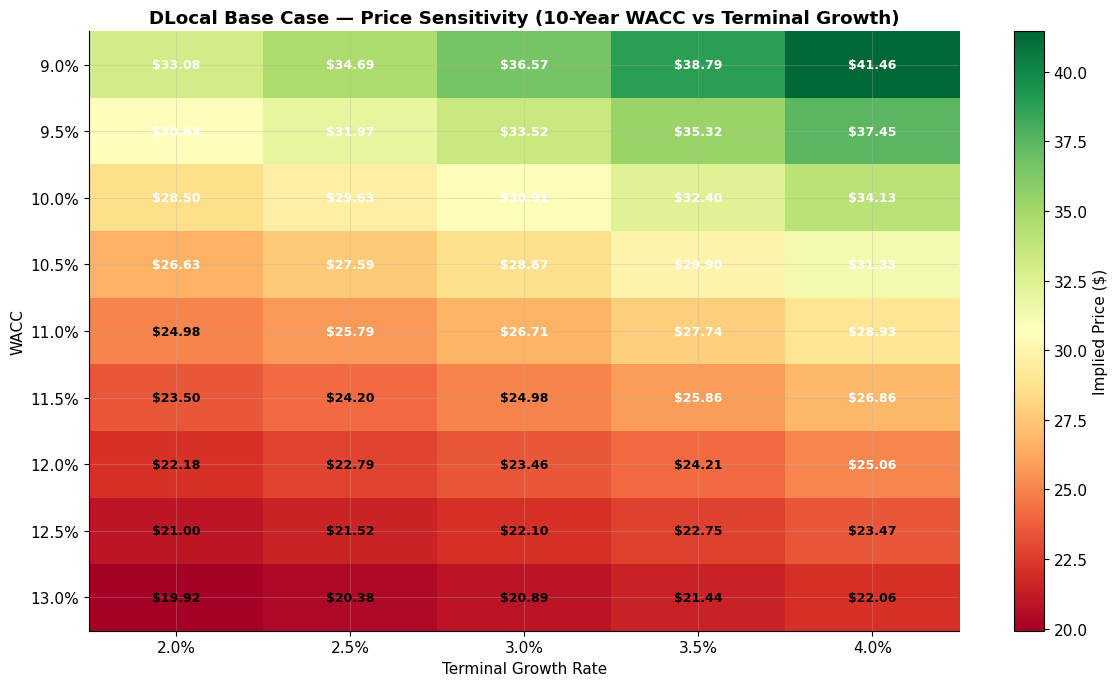

In [18]:
# ============================================================
# CELL GROUP 6: SENSITIVITY ANALYSIS (10-YEAR MODEL)
# ============================================================

def dcf_price(wacc, tg, fcfs, net_cash_k=451_800, shares_m=305):
    """Quick DCF price calculation for sensitivity table."""
    n_years = len(fcfs)
    pv_fcfs = sum(fcf / (1 + wacc) ** (i + 1) for i, fcf in enumerate(fcfs))
    terminal_fcf = fcfs[-1] * (1 + tg)
    tv = terminal_fcf / (wacc - tg)
    pv_tv = tv / (1 + wacc) ** n_years
    ev = pv_fcfs + pv_tv
    equity_value = ev + net_cash_k
    return equity_value / (shares_m * 1000)

# Build 10-year FCF list from both Phase 1 and Phase 2
base_proj = projections['Base']
base_fade = fade_projections['Base']
base_fcfs = []
for yr in list(base_proj.index) + list(base_fade.index):
    df = base_proj if yr in base_proj.index else base_fade
    ebitda = df.loc[yr, 'Adj_EBITDA']
    taxes = ebitda * 0.15
    capex = abs(df.loc[yr, 'Capex'])
    wc_chg = df.loc[yr, 'Revenue'] * 0.01
    base_fcfs.append(ebitda - taxes - capex - wc_chg)

n_years = len(base_fcfs)  # 10

wacc_range = [0.09, 0.095, 0.10, 0.105, 0.11, 0.115, 0.12, 0.125, 0.13]
tg_range = [0.02, 0.025, 0.03, 0.035, 0.04]

print('══════════════════════════════════════════════════════════════')
print('  SENSITIVITY ANALYSIS — BASE CASE IMPLIED PRICE (10-Year)')
print('  WACC vs. Terminal Growth Rate')
print('══════════════════════════════════════════════════════════════')

# Build sensitivity table
sens_data = {}
for tg in tg_range:
    col = []
    for w in wacc_range:
        if w > tg:  # ensure convergence
            price = dcf_price(w, tg, base_fcfs)
            col.append(price)
        else:
            col.append(np.nan)
    sens_data[f'TG {tg:.1%}'] = col

sens_df = pd.DataFrame(sens_data, index=[f'WACC {w:.1%}' for w in wacc_range])
print(sens_df.to_string(float_format=lambda x: f'${x:.2f}'))

# Heatmap
fig, ax = plt.subplots(figsize=(12, 7))
data = sens_df.values.astype(float)
im = ax.imshow(data, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(tg_range)))
ax.set_xticklabels([f'{tg:.1%}' for tg in tg_range])
ax.set_yticks(range(len(wacc_range)))
ax.set_yticklabels([f'{w:.1%}' for w in wacc_range])
ax.set_xlabel('Terminal Growth Rate')
ax.set_ylabel('WACC')
ax.set_title('DLocal Base Case — Price Sensitivity (10-Year WACC vs Terminal Growth)', fontweight='bold')

for i in range(len(wacc_range)):
    for j in range(len(tg_range)):
        val = data[i, j]
        if not np.isnan(val):
            color = 'white' if val < 14 or val > 25 else 'black'
            ax.text(j, i, f'${val:.2f}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)

plt.colorbar(im, label='Implied Price ($)')
plt.tight_layout()
plt.show()


In [19]:
# ── 2) Scenario Summary & Peer Comparison ────────────────────

print('=' * 60)
print('  DCF VALUATION SUMMARY (10-Year Model)')
print('=' * 60)

for s in ['Bull', 'Base', 'Bear']:
    r = dcf_results[s]
    p = projections[s]
    p_fade = fade_projections[s]
    print(f'\n  {s.upper()} CASE:')
    print(f'    Implied Price:      ${r["price_diluted"]:.2f}')
    print(f'    Enterprise Value:   ${r["ev"]/1e6:,.0f}M')
    print(f'    TV % of EV:         {r["tv_pct"]:.0%}')
    print(f'    ── Phase 1 (2030) ──')
    print(f'    2030E Revenue:      ${p.loc[2030, "Revenue"]/1000:>8,.0f}M')
    print(f'    2030E Adj EBITDA:   ${p.loc[2030, "Adj_EBITDA"]/1000:>8,.0f}M')
    print(f'    2030E EBITDA Margin:{p.loc[2030, "EBITDA_Margin"]:>8.1%}')
    print(f'    ── Phase 2 (2035) ──')
    print(f'    2035E Revenue:      ${p_fade.loc[2035, "Revenue"]/1000:>8,.0f}M')
    print(f'    2035E EBITDA Margin:{p_fade.loc[2035, "EBITDA_Margin"]:>8.1%}')
    print(f'    2035E FCF:          ${p_fade.loc[2035, "FCF"]/1000:>8,.0f}M')
    print(f'    Rev CAGR (25-30):   {(p.loc[2030, "Revenue"]/base_yr["revenue_k"])**(1/5)-1:.1%}')
    print(f'    Rev CAGR (30-35):   {(p_fade.loc[2035, "Revenue"]/p.loc[2030, "Revenue"])**(1/5)-1:.1%}')

# Exit multiple cross-check (now uses 2035 terminal year)
print(f'\n\n{"=" * 60}')
print('  EXIT MULTIPLE CROSS-CHECK (PV at 11.5% WACC, 10-Year)')
print('=' * 60)

discount_factor = (1 + 0.115) ** 10
net_cash = base_yr['cash_k']
shares = base_yr['shares_diluted']

print(f'\n  EV/EBITDA Exit Multiple (2035E):')
print(f'  {"Multiple":<10}', end='')
for s in ['Bull', 'Base', 'Bear']:
    print(f'{s:>12}', end='')
print()

for mult in [10, 12, 15, 18, 20]:
    print(f'  {mult}x        ', end='')
    for s in ['Bull', 'Base', 'Bear']:
        ebitda_term = fade_projections[s].loc[2035, 'Adj_EBITDA']
        ev_term = ebitda_term * mult
        eq_val = (ev_term + net_cash) / discount_factor
        price = eq_val / (shares * 1000)
        print(f'  ${price:>8.2f}', end='')
    print()

print(f'\n  P/E Exit Multiple (2035E):')
print(f'  {"Multiple":<10}', end='')
for s in ['Bull', 'Base', 'Bear']:
    print(f'{s:>12}', end='')
print()

for mult in [15, 20, 25, 30]:
    print(f'  {mult}x        ', end='')
    for s in ['Bull', 'Base', 'Bear']:
        ni_term = fade_projections[s].loc[2035, 'Net_Income']
        eq_val = ni_term * mult / discount_factor
        price = eq_val / (shares * 1000)
        print(f'  ${price:>8.2f}', end='')
    print()

# Peer comparison
print(f'\n\n{"=" * 60}')
print('  PEER COMPARISON')
print('=' * 60)

peers = pd.DataFrame({
    'Company': ['DLO', 'PAGS', 'STNE', 'ADYEN', 'MELI (payments)', 'PAYONEER'],
    'Focus': ['EM payments', 'Brazil', 'Brazil', 'Global', 'LatAm e-comm', 'Cross-border'],
    'LTM_Rev_M': [1213, 4500, 3200, 2400, 24000, 950],   # DLO LTM = Q2'25-Q1'26
    'Rev_Growth': ['~56%', '~12%', '~7%', '~19%', '~30%', '~16%'],
    'EV_Rev': [2.7, 1.0, 1.3, 8.1, 4.0, 2.2],
    'EV_EBITDA': [11, 8, 8, 15, 22, 11],
    'PE': [19, 9, 9, 30, 35, 16],
}).set_index('Company')

print(peers.to_string())


  DCF VALUATION SUMMARY (10-Year Model)

  BULL CASE:
    Implied Price:      $37.98
    Enterprise Value:   $11M
    TV % of EV:         60%
    ── Phase 1 (2030) ──
    2030E Revenue:      $   4,610M
    2030E Adj EBITDA:   $   1,095M
    2030E EBITDA Margin:   23.8%
    ── Phase 2 (2035) ──
    2035E Revenue:      $   9,031M
    2035E EBITDA Margin:   22.6%
    2035E FCF:          $   1,679M
    Rev CAGR (25-30):   33.3%
    Rev CAGR (30-35):   14.4%

  BASE CASE:
    Implied Price:      $26.04
    Enterprise Value:   $7M
    TV % of EV:         57%
    ── Phase 1 (2030) ──
    2030E Revenue:      $   3,787M
    2030E Adj EBITDA:   $     810M
    2030E EBITDA Margin:   21.4%
    ── Phase 2 (2035) ──
    2035E Revenue:      $   6,434M
    2035E EBITDA Margin:   20.7%
    2035E FCF:          $   1,089M
    Rev CAGR (25-30):   28.2%
    Rev CAGR (30-35):   11.2%

  BEAR CASE:
    Implied Price:      $14.49
    Enterprise Value:   $4M
    TV % of EV:         53%
    ── Phase 1 (2030) ──

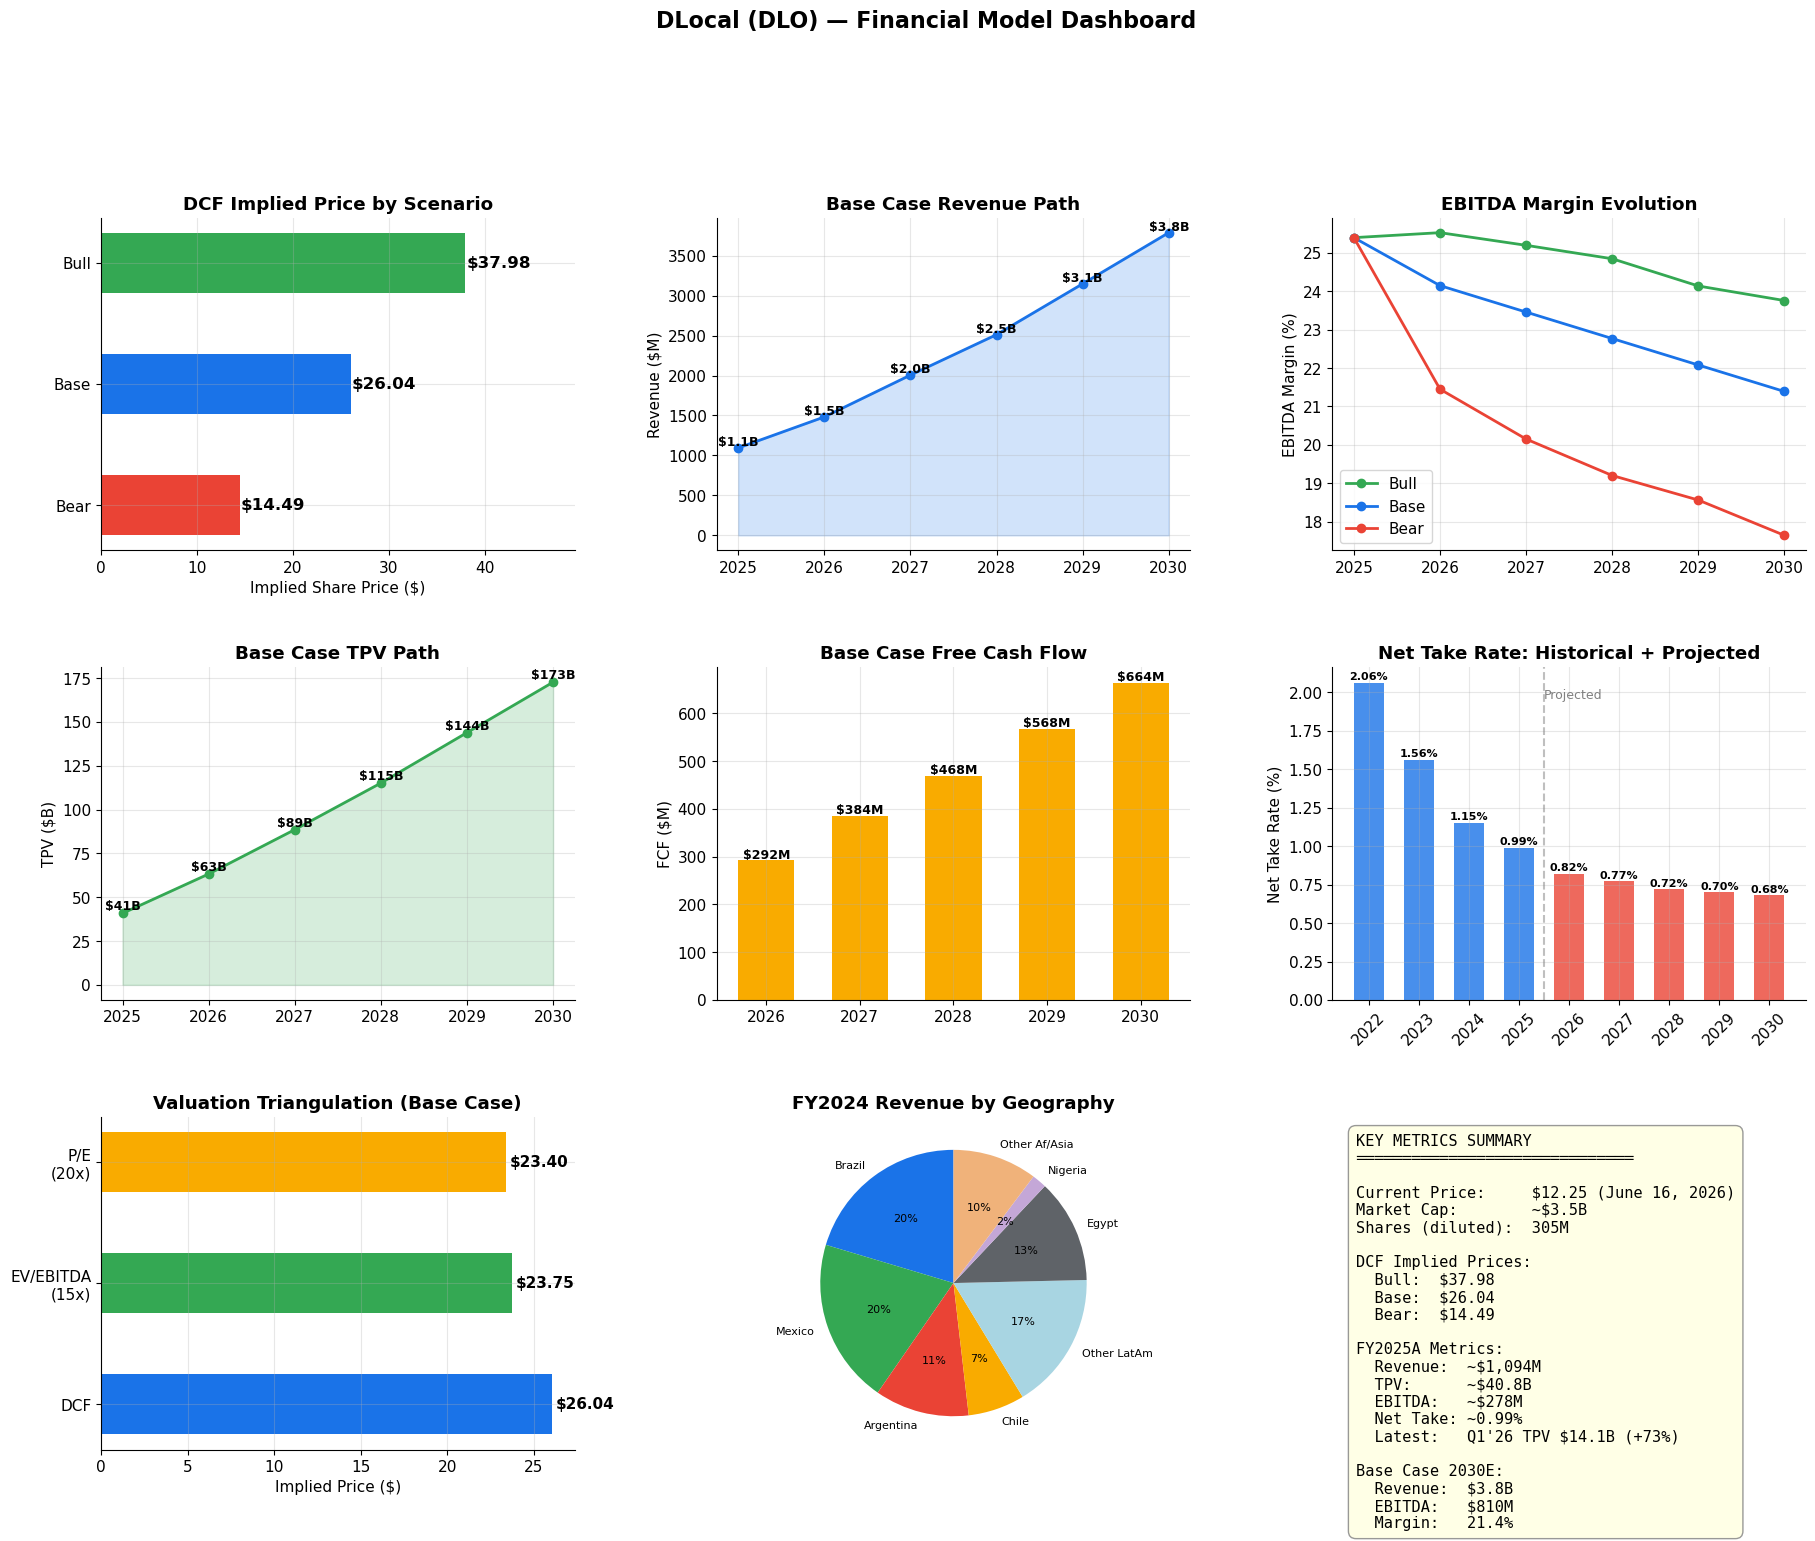


  MODEL COMPLETE
  Generated: June 2026
  Data sources: DLocal 20-F (FY2024-25), quarterly earnings releases
  FY2025 audited actuals; Q1 2026 reported actuals incorporated
  All projections are estimates subject to significant uncertainty.


In [20]:
# ── 3) Key Metrics Dashboard & Final Output ──────────────────

fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
scenario_colors = {'Bull': COLORS['secondary'], 'Base': COLORS['primary'], 'Bear': COLORS['accent']}

# 1) Scenario price comparison
ax = fig.add_subplot(gs[0, 0])
names = ['Bear', 'Base', 'Bull']
prices = [dcf_results[n]['price_diluted'] for n in names]
colors_bar = [scenario_colors[n] for n in names]
bars = ax.barh(names, prices, color=colors_bar, height=0.5)
for bar, p in zip(bars, prices):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'${p:.2f}', va='center', fontweight='bold', fontsize=12)
ax.set_xlabel('Implied Share Price ($)')
ax.set_title('DCF Implied Price by Scenario', fontweight='bold')
ax.set_xlim(0, max(prices) * 1.3)

# 2) Revenue bridge
ax = fig.add_subplot(gs[0, 1])
yrs_path = [2025] + proj_years
rev_path = [base_yr['revenue_k'] / 1000] + [projections['Base'].loc[yr, 'Total_Revenue'] / 1000 for yr in proj_years]
ax.fill_between(range(len(yrs_path)), rev_path, alpha=0.2, color=COLORS['primary'])
ax.plot(range(len(yrs_path)), rev_path, 'o-', color=COLORS['primary'], linewidth=2, markersize=6)
for i, (y, r) in enumerate(zip(yrs_path, rev_path)):
    ax.text(i, r + 30, f'${r/1000:.1f}B', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(yrs_path)))
ax.set_xticklabels(yrs_path)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Base Case Revenue Path', fontweight='bold')

# 3) EBITDA margin evolution
ax = fig.add_subplot(gs[0, 2])
for s in ['Bull', 'Base', 'Bear']:
    margins = [base_yr['ebitda_margin'] * 100] + [projections[s].loc[yr, 'EBITDA_Margin'] * 100 for yr in proj_years]
    ax.plot(range(len(yrs_path)), margins, 'o-', color=scenario_colors[s], label=s, linewidth=2)
ax.set_xticks(range(len(yrs_path)))
ax.set_xticklabels(yrs_path)
ax.set_ylabel('EBITDA Margin (%)')
ax.set_title('EBITDA Margin Evolution', fontweight='bold')
ax.legend()

# 4) TPV growth path
ax = fig.add_subplot(gs[1, 0])
tpv_path = [base_yr['tpv_b']] + [projections['Base'].loc[yr, 'TPV_B'] for yr in proj_years]
ax.fill_between(range(len(yrs_path)), tpv_path, alpha=0.2, color=COLORS['secondary'])
ax.plot(range(len(yrs_path)), tpv_path, 'o-', color=COLORS['secondary'], linewidth=2, markersize=6)
for i, (y, t) in enumerate(zip(yrs_path, tpv_path)):
    ax.text(i, t + 2, f'${t:.0f}B', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(yrs_path)))
ax.set_xticklabels(yrs_path)
ax.set_ylabel('TPV ($B)')
ax.set_title('Base Case TPV Path', fontweight='bold')

# 5) FCF waterfall
ax = fig.add_subplot(gs[1, 1])
fcf_path = [projections['Base'].loc[yr, 'FCF'] / 1000 for yr in proj_years]
ax.bar(range(len(proj_years)), fcf_path, color=COLORS['gold'], width=0.6)
for i, (yr, f) in enumerate(zip(proj_years, fcf_path)):
    ax.text(i, f + 5, f'${f:,.0f}M', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(proj_years)))
ax.set_xticklabels(proj_years)
ax.set_ylabel('FCF ($M)')
ax.set_title('Base Case Free Cash Flow', fontweight='bold')

# 6) Net take rate trend (historical + projected)
ax = fig.add_subplot(gs[1, 2])
hist_rates = [2.06, 1.56, 1.15, 0.99]  # GP/TPV 2022-2025 (FY25 actual)
proj_rates = [assumptions['Base']['net_take_rate'][i] for i in range(5)]
all_rates = hist_rates + proj_rates
all_rate_years = [2022, 2023, 2024, 2025] + proj_years
colors_r = [COLORS['primary']] * 4 + [COLORS['accent']] * 5
ax.bar(range(len(all_rate_years)), all_rates, color=colors_r, width=0.6, alpha=0.8)
for i, (yr, r) in enumerate(zip(all_rate_years, all_rates)):
    ax.text(i, r + 0.02, f'{r:.2f}%', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(all_rate_years)))
ax.set_xticklabels(all_rate_years, rotation=45)
ax.set_ylabel('Net Take Rate (%)')
ax.set_title('Net Take Rate: Historical + Projected', fontweight='bold')
ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)
ax.text(3.5, max(all_rates) * 0.95, 'Projected', ha='left', fontsize=9, color='gray')

# 7) Valuation triangulation
ax = fig.add_subplot(gs[2, 0])
methods = ['DCF', 'EV/EBITDA\n(15x)', 'P/E\n(20x)']
# Calculate exit multiple prices
df_5yr = (1.115) ** 5
ebitda_15x = (projections['Base'].loc[2030, 'Adj_EBITDA'] * 15 + 333_000) / df_5yr / (305 * 1000)
pe_20x = projections['Base'].loc[2030, 'Net_Income'] * 20 / df_5yr / (305 * 1000)
vals = [dcf_results['Base']['price_diluted'], ebitda_15x, pe_20x]
ax.barh(methods, vals, color=[COLORS['primary'], COLORS['secondary'], COLORS['gold']], height=0.5)
for i, v in enumerate(vals):
    ax.text(v + 0.2, i, f'${v:.2f}', va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Implied Price ($)')
ax.set_title('Valuation Triangulation (Base Case)', fontweight='bold')

# 8) Geographic revenue pie (FY2024)
ax = fig.add_subplot(gs[2, 1])
regions_pie = ['Brazil', 'Mexico', 'Argentina', 'Chile', 'Other LatAm', 'Egypt', 'Nigeria', 'Other Af/Asia']
values_pie = [152, 149.2, 85.5, 51.2, 124.4, 94, 13.3, 76.5]
colors_pie = [COLORS['primary'], COLORS['secondary'], COLORS['accent'], COLORS['gold'],
              COLORS['light'], COLORS['neutral'], '#c4a7d7', '#f0b27a']
wedges, texts, autotexts = ax.pie(values_pie, labels=regions_pie, autopct='%1.0f%%',
                                   colors=colors_pie, startangle=90, textprops={'fontsize': 8})
ax.set_title('FY2024 Revenue by Geography', fontweight='bold')

# 9) Key metrics summary text
ax = fig.add_subplot(gs[2, 2])
ax.axis('off')
summary_text = (
    f'KEY METRICS SUMMARY\n'
    f'══════════════════════════════\n\n'
    f'Current Price:     $12.25 (June 16, 2026)\n'
    f'Market Cap:        ~$3.5B\n'
    f'Shares (diluted):  305M\n\n'
    f'DCF Implied Prices:\n'
    f'  Bull:  ${dcf_results["Bull"]["price_diluted"]:.2f}\n'
    f'  Base:  ${dcf_results["Base"]["price_diluted"]:.2f}\n'
    f'  Bear:  ${dcf_results["Bear"]["price_diluted"]:.2f}\n\n'
    f'FY2025A Metrics:\n'
    f'  Revenue:  ~$1,094M\n'
    f'  TPV:      ~$40.8B\n'
    f'  EBITDA:   ~$278M\n'
    f'  Net Take: ~0.99%\n'
    f'  Latest:   Q1\'26 TPV $14.1B (+73%)\n\n'
    f'Base Case 2030E:\n'
    f'  Revenue:  ${projections["Base"].loc[2030, "Revenue"]/1e6:,.1f}B\n'
    f'  EBITDA:   ${projections["Base"].loc[2030, "Adj_EBITDA"]/1e3:,.0f}M\n'
    f'  Margin:   {projections["Base"].loc[2030, "EBITDA_Margin"]:.1%}'
)
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
        va='top', ha='left', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

fig.suptitle('DLocal (DLO) — Financial Model Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n' + '=' * 60)
print('  MODEL COMPLETE')
print('=' * 60)
print(f'  Generated: June 2026')
print(f'  Data sources: DLocal 20-F (FY2024-25), quarterly earnings releases')
print(f'  FY2025 audited actuals; Q1 2026 reported actuals incorporated')
print(f'  All projections are estimates subject to significant uncertainty.')